# Feature analysis — `vol_over_rate` (σ_ev / λ_ev)

This notebook follows the project's standard feature-analysis **method** (the `price_dislocation`
template) and applies it to one feature: **`vol_over_rate`** — the ratio of a venue's volatility
yardstick to its rate yardstick, `σ_ev / λ_ev`, read at each grid anchor. The text explains what
to do and why; the code does it.

We build features for a model that forecasts one exchange's mid-price about 100 ms ahead. Three
crypto exchanges appear throughout — **byb** (Bybit), **bin** (Binance), **okx** (OKX) — and
**byb is the target**: the one we predict. ("Mid-price" = the midpoint between the best buy and
best sell quote.) The next section recaps the two-head model these features feed.

**The feature.** `σ_ev` is a venue's exp-weighted RMS mid-move (volatility *per move*); `λ_ev` is
that venue's mid-moves *per second* (the move rate). Their ratio `σ_ev / λ_ev` has units of
**seconds** — roughly *"how much volatility the venue packs into one move, times how long a move
takes."* It is high when moves are **big and slow**, low when moves are **small and fast**. This is
an **intensity-flavoured** quantity: it speaks to *how the next stretch of trading is paced*, which
is the rate head's question.

**Two things this pass adds over the first.** The first pass computed `σ_ev/λ_ev` for **byb only**
and swept a single shared span. This pass adds the two axes the template insists on:

1. **Per-exchange.** As the template does for the dislocation *gap*, we compute `σ_ev/λ_ev` for
   **each venue** — byb, okx, bin — from **that venue's own** mid-moves / book / trades, and ask
   whether each predicts **byb's** next 100 ms move. byb's own leg is the original (circular) one;
   the **okx and bin legs are cross-venue** and test a genuinely different question — *does another
   venue's pace lead byb's?* §6 sweeps the heat-maps per-exchange; §9 runs the per-exchange-vs-single
   analysis.
2. **The full lookback family.** `σ_ev` and `λ_ev` need not share a span. We sweep the **vol span**
   and the **rate span** *independently* — a 2-D `σ_ev`-span × `λ_ev`-span heat-map — and pick the
   best cell per head, rather than reading a single hand-picked shared span.

**A blunt caveat up front (read this).** For **byb**, `σ_ev` and `λ_ev` are *also the gate's vol/rate
controls* (`vol_level = log σ_ev`, `rate_level = log λ_ev`). And `log(σ_ev/λ_ev) = vol_level −
rate_level` is an **exact linear combination of two of the controls**. So the §6 marginal-value
gate — what the feature adds *over* the controls in a linear model — is **near-circular by
construction for the byb leg**, and we expect ≈ **0** marginal value there. **The okx and bin legs
are NOT circular** — they are *other venues'* vol/rate, not byb's controls — so their marginal value
is a real, honest number, and §6/§9 report it as such: *does any cross-venue σ_ev/λ_ev lead byb
beyond byb's own leg?*

**A feature is "done" when two checks pass:**
- **The oracle (§4)** — the code really computes what we think it does, **for every per-exchange leg**.
- **The hygiene gates (§5–§6)** — read with the circularity caveat firmly in mind for the byb leg,
  and as a genuine test for the cross-venue legs.

## The model these features feed: two heads

A feature is only worth something if it helps the model predict, so it's worth knowing what the
model does. We forecast how byb's mid-price moves over the next ~100 ms, and split that into two
simpler questions — the two **heads**:

**Price head — which way and how far?** Over the next few price-moves, what is the *signed* move
(direction *and* size), as a distribution, in units of byb's recent **volatility** — the
**volatility yardstick** `σ_ev` (the exp-weighted RMS of byb's *actual* mid-moves)? So the head's
target is `price change ÷ σ_ev`.

**Rate head — how many moves?** Busy markets pack many price-moves into the window, quiet ones
few. This head predicts the *count* of moves over the next 100 ms as a distribution, measured
against the recent pace — the **rate yardstick** `λ_ev` — so its target is `count ÷ λ_ev`.

**What's a yardstick?** A causal, trailing estimate of a venue's *volatility* (`σ_ev`) and move
*rate* (`λ_ev`), from past data only — a regime gauge. Both are EMAs **decayed on the trade clock**
(`α = 2/(span+1)`) but **updated between trades** — they react to every mid-move, so they read live
at every instant. (`σ_ev` is the exp-weighted RMS of *actual* mid-moves — read as an `E/W` ratio so
the many non-move trades cancel out; `λ_ev` is a ratio of two EMAs — the exp-weighted move-count `W`
÷ the exp-weighted seconds-per-trade = moves per second.) Like every average here, they live on the
trade-tick clock — never wall-clock or a hard window. **The model's own yardsticks are byb's**; this
feature computes the *same construction* for each venue, which is the whole point of the per-exchange
axis.

**This feature *is* a venue's two yardsticks' ratio.** Most features *borrow* a yardstick to
normalise themselves. `vol_over_rate` is unusual: it is built *entirely out of the two yardsticks*.
That is exactly why the marginal-value gate is near-circular for the **byb** leg (§6). The
interesting questions are therefore: *is byb's `σ_ev/λ_ev` a useful regime coordinate on its own,
and at which (vol, rate) span pair does it read cleanest* (§6–§7), and *does any **other** venue's
`σ_ev/λ_ev` lead byb's next move beyond byb's own leg* (§6, §9) — the genuinely non-circular question.

**Why split into two heads?** A move over a window is *how many* little moves times *how big* each
is. Pulling "how many" (rate) apart from "how big" (price) lets each head learn a steadier thing.
Backed by the classic **subordination** model of asset prices (Clark, 1973; Ané & Geman, 2000):
returns over fixed clock-time look messy but become well-behaved once you condition on the
*number* of events. `vol_over_rate` lives squarely in that picture — it is literally
*per-move size ÷ event rate*, a one-number summary of the subordinator's local state.

## Guard rails — do this, not that

Hard rules, learned the hard way. Follow them unless you have a specific, written reason not to.

**Don't**
- **Don't assume a fixed leader.** No exchange always leads. We build `σ_ev/λ_ev` **the same way
  for every venue** and keep them all; the §6/§9 sweeps say where (and at what span) a cross-venue
  leg actually leads byb, rather than privileging one.
- **Don't normalize reflexively.** `σ_ev/λ_ev` is *already a ratio of two EMAs* — it needs no
  further vol/rate division. Dividing it again by `σ_ev` would just hand back `1/λ_ev`.
- **Don't trust a correlation** until it survives the regime controls (rate and vol). For the **byb**
  leg that test is **near-circular** — the feature is a function of byb's controls — so we read the
  gate's ≈0 as *expected*. For the **okx/bin** legs the same gate is a real test, because those are
  *other venues'* vol/rate, not byb's controls.
- **Don't ship a feature without the oracle** (§4) matching a dead-simple independent version —
  **for every per-exchange leg**.
- **Don't peek ahead.** Every value uses only data at-or-before its own timestamp.

**Do**
- **Do start with a falsifiable hypothesis** — a mechanism for why it should work, and what would
  prove it wrong.
- **Do make every average a trade-tick EMA.** *Every* smoother — each venue's `σ_ev`, `λ_ev`, the
  seconds-per-trade leg — is an exponential moving average **decayed once per trade-timestamp**
  (`α = 2/(span+1)`) yet **updated on every live mid-move between trades**, never a wall-clock
  average and never a hard/boxcar window. That keeps the state **O(1)** and bit-identical online
  vs offline. We validate it against a plain one-event-at-a-time loop on a real block in §4 — for
  every venue.
- **Do make every EMA react to *every* relevant event — never read a stale state.** Decay rides
  the trade clock, but the read must reflect every mid-move since the last trade.
- **Do treat all records sharing a timestamp as ONE event.** A burst of book updates and trades at
  the *exact same instant* did not arrive in an order — they are one event. Apply them all, then
  register a single update: one mid, one move, one decay. `σ_ev` counts squared mid-*moves*, so N
  simultaneous records would fabricate N−1 fake moves and inflate the volatility. The decay clock
  is the only place order matters — a timestamp with trades advances the clock **once**.
- **Do read a sparse flow as `E / W`.** `σ_ev` is exactly such a flow — a venue moves on only *some*
  events — so it is two EMAs (the squared-return sum `E` and the move-count `W`), read as the ratio
  `√(E/W)`, which cancels the in-between decay and the warm-up bias. `λ_ev` reuses that same `W`,
  divided by an EMA of seconds-per-trade. This is also why per-venue stats fall out of the **one
  shared clock**: the `E/W` cancels the foreign-event decay, so each venue's own-clock EMA is
  recovered at a rescaled span (tight at large N, fraying at small N — exactly where cross-venue
  lead/lag lives).
- **Do sweep the whole time-scale family** — here the **two** spans (`σ_ev` and `λ_ev`)
  independently, a 2-D grid — and let the data say which cell reads cleanest, per head.
- **Do keep every exchange.** Compute the feature identically per venue and let the analysis weight
  whichever leads; never hard-code byb as the only venue (that was the first pass's omission).
- **Do test against both heads — but feed both the *signed* feature.** `vol_over_rate` is a
  non-negative magnitude (a ratio of positives), so it has no sign to speak of — it is naturally a
  **rate-head / intensity** feature. We still check both targets as diagnostics.

## 1. What the feature is, and why it might work

Every feature starts with a one-line summary and a **hypothesis you could be wrong about**.

| | |
|---|---|
| **what** | a venue's volatility-per-move `σ_ev` divided by its move-rate `λ_ev` — a ratio (units: seconds), computed **per venue** (byb, okx, bin) and swept over the `σ_ev` and `λ_ev` spans independently |
| **feeds** | mainly the **rate head** (intensity: how many / how fast the next moves come); checked against the price head too |
| **predicts** | byb's mid-price 100 ms from now — chiefly *how busy* the next 100 ms will be |

**The idea.** Split a venue's recent behaviour into "how big is a typical move" (`σ_ev`) and "how
often does it move" (`λ_ev`). Their ratio `σ_ev / λ_ev` is large when moves are **big but
infrequent** (a jumpy, lurching regime) and small when moves are **small but frequent** (a smooth,
fast-ticking regime). That contrast is a clean one-number description of the *texture* of trading,
and texture tends to persist over the next 100 ms.

**Why it should work — and why per-exchange.** Market regimes are sticky on a 100 ms scale: a market
that is currently lurching tends to keep lurching. byb's *own* `σ_ev/λ_ev` reads byb's texture
directly. But the venues are coupled and not perfectly synchronous — **okx or bin may shift its
texture a beat before byb does**, so *another* venue's `σ_ev/λ_ev` can carry information about byb's
*next* stretch that byb's own value hasn't shown yet. That is the per-exchange hypothesis: at short
spans the cross-venue legs carry a distinct lead; at long spans the venues converge and one suffices.

**What would disprove it.** (byb leg) no relationship between byb's `σ_ev/λ_ev` and byb's forward
move-count / return-magnitude at any span. (cross-venue legs) the okx/bin `σ_ev/λ_ev` adds **no**
marginal value over byb's own — i.e. no venue leads byb's pace; they all collapse to byb's reading.

> **The circularity caveat (byb leg only).** byb's `σ_ev` and `λ_ev` are the model's vol and rate
> controls. `log(σ_ev/λ_ev) = log σ_ev − log λ_ev` is exactly `vol_level − rate_level`. So the §6
> gate asking "what does the **byb** feature add over `{vol_level, rate_level, …}`?" asks what a
> linear combination of two regressors adds over those same two: **nothing**, up to the monotone
> `exp(·)` wrinkle. We therefore *predict* ≈0 marginal value **for the byb leg**, and judge it
> instead by whether byb's `σ_ev/λ_ev` is informative (§7) and at which span it is cleanest (§6).
> **This caveat does NOT apply to the okx/bin legs** — they are other venues' vol/rate, orthogonal
> to byb's controls — so their marginal value is the honest cross-venue lead/lag test.

## Choosing the EMA — the part that's easy to get silently wrong

Every smoother here is an EMA on the **trade clock**: its **decay** steps once per *trade-timestamp*
(`α = 2/(span+1)`), but its **value updates on every mid-move in between**, so a read between trades
is never stale. Two choices decide whether the EMA is even *correct*:

**Choice 1 — which EMA, and how you read it** (`boba.ema`):

- `σ_ev` is a **sparse flow** — a venue moves on only *some* events — so it is a **`KernelMeanEMA`**,
  the self-normalising `E / W`: push `return²` (weight 1) only on a real move, decay every trade,
  read `σ_ev = √(E/W)` = RMS move *per move*. The `W` denominator counts only the events carrying the
  quantity, so the many non-move trades cancel instead of counting as zeros.
- `λ_ev` reuses that same exp-weighted move-count `W` and divides it by an **`EventEMA`** of
  **seconds-per-trade** (stepped once per trade-timestamp, held flat between trades). So
  `λ_ev = W / E[Δt]` = mid-moves per second.

**Choice 2 — *when* you push a value in** (the injection clock — separate from the decay clock).
Decay is always once per trade-timestamp; injection differs per quantity:

| push rule | what it measures | use for |
|---|---|---|
| only on a real venue mid-move, skip the rest | a **per-move mean** of `r²`; non-moves are non-observations, not zeros | `σ_ev` (the `E`, `W`) |
| once per trade-timestamp | a per-trade EMA of the gap between trades | `λ_ev`'s seconds-per-trade leg |

The trap: push a `0` on a non-move trade and "vol per move" silently becomes "vol per *trade*"
(contaminated by the trade rate). Both `σ_ev` and `λ_ev` obey the two between-trade rules: **react
to every mid-move** (read fresh, never stale) and **records sharing a timestamp are ONE event**
(apply all, then one move, then one decay). The §4 oracle enforces both, **for every venue**.

## 2. The exact definition

A definition has to get three things right.

**Causal** — it uses only data up to the moment it's computed; no peeking. (A stray forward-fill
is the usual way to break this by accident.)

**Measured on the trade clock** — we count progress in *trades* (one tick per trade-timestamp on
any exchange — simultaneous prints are one tick), not in clock-seconds, so the feature's meaning
stays steady whether trading is fast or slow. Book updates between trades refresh what the EMAs
*read*, but do **not** advance the clock — only a trade does, decaying each EMA once. **All venues'
trades share this one clock**; each venue's `σ_ev/λ_ev` injects on its *own* mid-moves but decays on
the *shared* trade clock (the `E/W` ratio recovers each venue's own-clock statistic — see §4).

**Comparable across calm and wild markets** — `σ_ev/λ_ev` is **already a ratio**, so it needs *no*
further normalisation. Its units are **seconds** — a true physical scale, the same in calm and wild
markets — which is exactly why it is a usable coordinate as-is.

Put together:

**2a — The shape** (the whole idea, in one line):

`feature(venue) = σ_ev(venue) / λ_ev(venue)`     (units: seconds; high = big-and-slow moves)

**2b — The EMAs we use, and how they update** (per venue):

- **`σ_ev`** — a **`KernelMeanEMA`** read as `E / W`: push that venue's `return²` (weight 1) only on a
  real mid-move, decay every trade-timestamp, read `σ_ev = √(E/W)`.
- **`λ_ev`** — the same exp-weighted move-count `W` divided by an **`EventEMA`** of seconds-per-trade
  (`E[Δt]`, stepped once per trade-timestamp). `λ_ev = W / E[Δt]` = moves per second.
- Both are read **at the grid anchor** with their live partial epoch — every mid-move since the last
  trade is folded in, so the read is current between trades, never frozen at the last trade.

The two knobs are **the `σ_ev` span and the `λ_ev` span**; §6 sweeps them independently as a 2-D
grid. The per-venue mid source follows the project policy: byb/okx use the merged (front_levels +
trade-fusion) mid; **bin must use front_levels** (merged_levels is disallowed for bin perp in
`boba.io` — it raises).

The cell below loads the data, builds the shared trade clock, and computes **per-venue** move
streams, then defines a `yardsticks(venue, anchors, vol_span, rate_span)` that returns that venue's
`σ_ev`, `λ_ev` as `E/W` flows on the shared clock — identical machinery to the template, now keyed
by venue and with independent spans.

In [1]:
import numpy as np, polars as pl
import matplotlib.pyplot as plt
from scipy.signal import lfilter
from scipy.stats import spearmanr
from boba.io import list_blocks, load_block

COIN        = "eth_usdt_p"
TARGET      = "byb_eth_usdt_p"                    # the exchange we predict (byb's NEXT move is the target for every leg)
EXCHANGES   = ["byb", "okx", "bin"]              # EVERY venue gets its own σ_ev/λ_ev — byb is the circular leg; okx/bin are cross-venue
# freshest mid per exchange. front_levels = raw best-bid/ask snapshots; merged_levels = those snapshots fused
# with trades for a fresher mid. byb/okx use merged_levels; bin MUST use front_levels — merged_levels is DISALLOWED for
# bin perp in boba.io (it raises). This is a policy, not a tuning choice.
MID_STREAM  = {"bin": "front_levels", "byb": "merged_levels", "okx": "merged_levels"}
# The FULL lookback family: σ_ev span and λ_ev span swept INDEPENDENTLY (a 2-D heat-map), not one shared span.
VOL_SPANS   = [2000, 5000, 10000, 20000, 40000]  # σ_ev (volatility-per-move) yardstick spans
RATE_SPANS  = [2000, 5000, 10000, 20000, 40000]  # λ_ev (move-rate) yardstick spans
HORIZON_NS  = 100 * 1_000_000                    # how far ahead we predict (100 ms, in nanoseconds)
YARDSTICK_N = 10000                              # the reference span for the §5 CONTROLS (byb's vol_level/rate_level) — the feature itself sweeps the 2-D grid
block       = list_blocks(TARGET, "front_levels")[0]   # one ~24h slice of recorded data

# load each exchange's mid-price stream (rows already arrive in time order)
def load_mid(ex):
    df = (load_block(block, f"{ex}_{COIN}", MID_STREAM[ex]).select("rx_time", "bid_prc", "ask_prc").drop_nulls())
    return df["rx_time"].cast(pl.Int64).to_numpy(), (df["bid_prc"].to_numpy() + df["ask_prc"].to_numpy()) / 2
mids = {ex: load_mid(ex) for ex in EXCHANGES}

# the trade clock: one tick per trade-TIMESTAMP. Simultaneous prints (one order sweeping levels) are ONE event -> ONE tick.
trade_ts = []
for ex in EXCHANGES:
    td = (load_block(block, f"{ex}_{COIN}", "trade").select("rx_time", "prc", "qty")
          .filter((pl.col("prc") > 0) & (pl.col("qty") > 0)))         # drop bad prc=qty=0 prints
    trade_ts.append(td["rx_time"].cast(pl.Int64).to_numpy())
trade_prints = np.concatenate(trade_ts)
merged_ts = np.unique(trade_prints)                               # collapse same-timestamp prints: at most one decay per timestamp
n_ticks = len(merged_ts)
print(f"trade clock: {n_ticks:,} ticks (timestamps) from {len(trade_prints):,} trade prints (all venues)")

# ---- per-venue move streams: collapse same-timestamp rows to ONE mid, take the log-return per timestamp, keep REAL moves ----
# Each venue decays on the SHARED trade clock but injects on its OWN mid-moves; the E/W ratio recovers its own-clock σ_ev/λ_ev.
def move_stream(ex):
    rx0, mid0 = mids[ex]
    keep = np.concatenate([rx0[1:] != rx0[:-1], [True]])                         # collapse same-TIMESTAMP rows to ONE update (the final mid)
    rx, mid = rx0[keep], mid0[keep]
    lm = np.log(mid)
    blr = np.empty_like(lm); blr[0] = 0.0; blr[1:] = np.diff(lm)                 # log-return per timestamp
    mv = blr != 0.0                                                             # a REAL mid-move: ONE per timestamp where the mid changed
    return dict(rx=rx, mid=mid, mv_rx=rx[mv], mv_r2=blr[mv] ** 2,
                cum_mv=np.concatenate([[0.0], np.cumsum(mv.astype(float))]))    # running move count (rate-head target uses byb's)
MS = {ex: move_stream(ex) for ex in EXCHANGES}

byb_rx, byb_mid, cum_mv = MS["byb"]["rx"], MS["byb"]["mid"], MS["byb"]["cum_mv"]  # byb specifics used for the TARGET (every leg predicts byb)
byb_dt = np.zeros(n_ticks); byb_dt[1:] = np.diff(merged_ts) / 1e9                 # seconds between consecutive trades (per-trade, shared clock)

def _ewma(x, span):                                                # per-trade EMA (for the seconds-per-trade leg of λ_ev)
    a = 2.0 / (span + 1.0); return lfilter([a], [1.0, -(1.0 - a)], x)
def _flow_at(ex, anchors, val, span):       # EWMA of `val` over venue ex's MOVE stream, decayed once per trade-timestamp, read AT each anchor
    a = 2.0 / (span + 1.0)
    mv_rx = MS[ex]["mv_rx"]
    k = np.searchsorted(merged_ts, mv_rx, "left")                               # trades strictly before each move (a same-rx trade decays it)
    ep = np.bincount(k, weights=val, minlength=n_ticks + 1)                     # per-trade-epoch sums
    x = np.zeros(n_ticks + 1); x[1:] = a * (1.0 - a) * ep[:-1]
    com = lfilter([1.0], [1.0, -(1.0 - a)], x)                                  # committed E just after each trade
    ta = np.searchsorted(merged_ts, anchors, "right") - 1                       # last trade <= anchor
    cs = np.concatenate([[0.0], np.cumsum(val)])                               # prefix sums over the move stream (the partial epoch)
    partial = cs[np.searchsorted(mv_rx, anchors, "right")] - cs[np.searchsorted(mv_rx, merged_ts[ta], "right")]
    return com[ta + 1] + a * partial
def yardsticks(ex, anchors, vol_span, rate_span):     # σ_ev (span=vol_span), λ_ev (span=rate_span) for venue ex — independent spans
    e_sq = _flow_at(ex, anchors, MS[ex]["mv_r2"], vol_span)                     # E: exp-weighted squared moves (σ_ev's span)
    e_mv_v = _flow_at(ex, anchors, np.ones(MS[ex]["mv_r2"].size), vol_span)     # W at the σ_ev span (σ_ev's denominator)
    e_mv_r = _flow_at(ex, anchors, np.ones(MS[ex]["mv_r2"].size), rate_span)    # W at the λ_ev span (λ_ev's numerator)
    e_dt = _ewma(byb_dt, rate_span)[np.searchsorted(merged_ts, anchors, "right") - 1]  # seconds/trade on the shared clock (λ_ev's span)
    sig = np.sqrt(e_sq / np.maximum(e_mv_v, 1e-12))                            # σ_ev: RMS mid-move (E/W — non-moves cancel)
    lam = e_mv_r / np.maximum(e_dt, 1e-12)                                     # λ_ev: mid-moves per second
    return sig, lam
print(f"yardsticks(venue, anchors, vol_span, rate_span): per-venue σ_ev/λ_ev on the shared clock, independent spans")

trade clock: 1,682,255 ticks (timestamps) from 6,198,188 trade prints (all venues)


yardsticks(venue, anchors, vol_span, rate_span): per-venue σ_ev/λ_ev on the shared clock, independent spans


> **Independent spans, one note.** When `vol_span == rate_span`, the `W` used in `σ_ev = √(E/W)` and
> the `W` used in `λ_ev = W/E[Δt]` are the **same** exp-weighted move-count (computed once). With
> independent spans they are two different EMAs of the same move stream — `σ_ev` uses `W` at the
> vol span, `λ_ev` uses `W` at the rate span. The seconds-per-trade leg `E[Δt]` lives on the
> **shared** clock and takes the **rate** span (it is part of `λ_ev`). Everything else is unchanged
> from the first pass; setting `vol_span = rate_span = YARDSTICK_N` reproduces it exactly.

## 3. Build it (twice)

Build the feature two ways: this fast array version for analysis, and — in production — a streaming
version that does constant work per trade (no growing buffers). They have to agree, which §4 checks.

The feature is a one-liner on top of the yardsticks: `vol_over_rate(venue, vol_span, rate_span) =
σ_ev(venue, vol_span) / λ_ev(venue, rate_span)`, read at every grid anchor. We lay an evaluation
grid every 50 ms (half the 100 ms horizon — plenty of samples; adjacent 100 ms outcome windows
overlap ~50%, so neighbouring samples are correlated, which is exactly why §5's walk-forward gate
uses an embargo), read byb's actual move over the next 100 ms (the price-head target), and the
forward move-count (the rate-head target). **All targets are byb's** — every per-exchange leg is
scored as a predictor of byb's next move.

In [2]:
# evaluation grid (causal) + forward targets — all targets are byb's (every leg predicts byb)
WARMUP = 5 * max(VOL_SPANS + RATE_SPANS)      # = 200000: enough trades for the slowest yardstick span to converge
anchor_ts      = np.arange(merged_ts[WARMUP], merged_ts[-1] - HORIZON_NS, 50 * 1_000_000)   # 50 ms grid, past warmup
tick_at_anchor = np.searchsorted(merged_ts, anchor_ts, "right") - 1                         # last trade-clock tick <= anchor
# byb's reference-span yardsticks (used for the §5 CONTROLS and the price-head target σ-units)
sigma_at_anchor, lam_at_anchor = yardsticks("byb", anchor_ts, YARDSTICK_N, YARDSTICK_N)
print(f"byb σ_ev median {np.nanmedian(sigma_at_anchor):.2e},  λ_ev median {np.nanmedian(lam_at_anchor):.2f} moves/s")

# price-head target — byb's signed 100 ms return ÷ σ_ev (σ-units), as in the template
mid_now    = byb_mid[np.searchsorted(byb_rx, anchor_ts, "right") - 1]
mid_fwd    = byb_mid[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right") - 1]
fwd_return = np.log(mid_fwd / mid_now)
target     = fwd_return / sigma_at_anchor                          # byb's 100 ms return ÷ σ_ev — the price head's target (σ-units)

def vol_over_rate(ex, vol_span, rate_span):         # THE FEATURE for venue ex: σ_ev(vol_span) / λ_ev(rate_span), read at each grid anchor
    sig, lam = yardsticks(ex, anchor_ts, vol_span, rate_span)
    return sig / np.maximum(lam, 1e-12)
for ex in EXCHANGES:
    print(f"  {ex}: feature median {np.nanmedian(vol_over_rate(ex, YARDSTICK_N, YARDSTICK_N)):.2e} s   on {len(anchor_ts):,} anchors")

byb σ_ev median 2.77e-05,  λ_ev median 1.15 moves/s


  byb: feature median 2.41e-05 s   on 1,634,976 anchors


  okx: feature median 2.91e-05 s   on 1,634,976 anchors


  bin: feature median 1.56e-05 s   on 1,634,976 anchors


## 4. Check the code is right — the oracle (a production-style streaming build), every venue

**Non-negotiable.** Reproduce the feature with a second, independent implementation and confirm the
two agree on real data — **for every per-exchange leg**. The oracle is the **production** reference:
an O(1) state machine you push **raw events** into — `on_book(...)` for a top-of-book update,
`on_trade(...)` for a trade — and read the current `σ_ev / λ_ev` **per venue** from `value()`. State
is a few scalar EMAs per venue — no buffers, no history, independent of how long it runs.

**The design:**
- Fed **only raw events**, each keyed by its full listing (e.g. `byb_eth_usdt_p`), so a perp and a
  spot on one exchange stay separate books. It builds each venue's mid **itself** (per `MID_STREAM`):
  byb/okx (merged) fuse trades into the book by newest-exchange-time; bin (book-only) takes the
  latest snapshot — matching each analysis mid.
- Events sharing a **timestamp are one event**: the driver applies them all, then calls
  **`refresh()` once** — which, **for each venue**, injects `σ_ev`'s `r²` on that venue's mid-move
  (read fresh, never stale), then advances the clock **once** *if any trade landed* (decay each
  venue's `σ_ev` `E`/`W`, step the shared seconds-per-trade EMA). The clock advances on **every**
  trade-timestamp — even before a venue's mid exists — to match the vectorized per-tick decay.
- `value(venue)` returns `√(E/W) / (W / E[Δt])` for that venue — current at the instant it's read.

We feed the **whole raw stream** — every venue's book updates and trades — into **one** builder and
read **all three** features at each grid anchor. If the online build reproduces §3's vectorized
feature on real data **for every venue**, all are right. (The decay clock is shared, so one builder
holds all three venues' yardsticks; only the seconds-per-trade leg is shared between them.)

A subtle correctness point the oracle pins down (it is what makes the diff *bit-exact*): a mid-move
landing at the **same timestamp** as a trade must be **injected before that trade decays the clock**,
and the clock must advance on **every** trade-timestamp regardless of whether a venue's book is warm
yet. Get either wrong and a leg's diff drifts to ~1e-5; get both right and it collapses to ~1e-18.

In [3]:
import boba.io as io
import math
from boba.ema import KernelMeanEMA, EventEMA   # E/W flow mean (σ_ev's E,W and λ_ev's W) + plain EMA (seconds-per-trade), src/boba/ema.py

class LiveVolOverRate:
    # Pure feature state machine for σ_ev / λ_ev, computed for EVERY venue at once on the shared trade clock. Each venue has
    # its own KernelMeanEMA (E/W flow over its squared mid-moves) for σ_ev; λ_ev = (that same W) / (a SHARED EventEMA of
    # seconds-per-trade). refresh() injects each venue's move r² (fresh, never stale), then advances the trade clock ONCE per
    # timestamp if a trade landed — decay every venue's E,W and step the seconds/trade EMA. The clock advances on EVERY
    # trade-timestamp (even before a venue's mid exists), matching the vectorized per-tick decay. State is O(1) per venue, all
    # scalar — no buffers, no history. The mid is built INSIDE: `fuse` listings fold trades into the book by newest-exchange-time
    # (= merged_levels); the rest are book-only, latest snapshot (= front_levels).
    def __init__(self, listings, span, fuse_trades):
        self.listings = list(listings)                                     # the venues whose σ_ev/λ_ev we compute (full listing tokens)
        self.fuse = set(fuse_trades)                                       # listings whose mid folds in trades (merged_levels); rest book-only
        self.bid = {}; self.bid_t = {}; self.ask = {}; self.ask_t = {}     # newest-by-exchange-time top-of-book, keyed by listing
        self.vol = {L: KernelMeanEMA(span) for L in self.listings}         # σ_ev per venue: E = exp-wt Σ r², W = exp-wt move count -> √(E/W); λ_ev reuses W
        self.dt = EventEMA(span)                                           # E[Δt]: SHARED per-trade EMA of seconds-per-trade (λ_ev denominator, common clock)
        self.prev = {L: None for L in self.listings}                       # each venue's last log-mid, to detect a real move
        self.was_trade_present = False                                     # did a trade land this timestamp? -> exactly one clock-step per timestamp
        self.last_ts = None                                                # rx of the previous trade-timestamp (for Δt)

    def _side(self, listing, is_ask, px, t):                              # keep this listing-side's newest-by-exchange-time price
        held_t = (self.ask_t if is_ask else self.bid_t)
        if t > held_t.get(listing, -1):
            (self.ask if is_ask else self.bid)[listing] = px; held_t[listing] = t

    def _mid(self, listing):
        b, a = self.bid.get(listing), self.ask.get(listing)
        return None if b is None or a is None else 0.5 * (b + a)

    def refresh(self, ts):                                                # ONE per TIMESTAMP: inject each venue's move, then advance the clock AT MOST ONCE
        traded, self.was_trade_present = self.was_trade_present, False      # consume the flag — simultaneous prints = one decay, not many
        for L in self.listings:                                          # σ_ev reacts to EVERY mid-move of its OWN venue — inject r² BEFORE the tick below
            m = self._mid(L)
            if m is not None:
                lt = math.log(m)
                if self.prev[L] is not None and lt != self.prev[L]:
                    self.vol[L].add((lt - self.prev[L]) ** 2)
                self.prev[L] = lt
        if traded:                                                     # a trade landed -> advance the clock once (on every trade-timestamp, even pre-warm)
            dt_sec = 0.0 if self.last_ts is None else (ts - self.last_ts) / 1e9
            self.dt.step(dt_sec); self.last_ts = ts                    # SHARED per-trade EMA of seconds/trade
            for L in self.listings: self.vol[L].tick()                 # decay each venue's σ_ev E and W one trade-tick

    def on_book(self, listing, t, bid, ask):                              # BBO update -> mutate that listing's mid only (the single per-timestamp refresh is the driver's job)
        if listing in self.fuse:                                         # merged-mid listing: newest-by-exchange-time
            self._side(listing, False, bid, t); self._side(listing, True, ask, t)
        else:                                                            # book-only listing (e.g. bin): latest snapshot wins
            self.bid[listing] = bid; self.ask[listing] = ask

    def on_trade(self, listing, t, px, lifts_ask):                       # trade -> fold into the mid (merged-mid listings only) and flag the timestamp as traded
        if listing in self.fuse: self._side(listing, lifts_ask, px, t)
        self.was_trade_present = True                                    # any trade this timestamp -> the clock advances once (in refresh)

    def value(self, listing):                                             # live feature for one venue: σ_ev / λ_ev, reading the freshest state — never stale
        v = self.vol[listing]; W = v.W
        if W <= 0.0: return float("nan")
        sig = math.sqrt(v.E / W)                                         # σ_ev = √(E/W)
        dt = self.dt.value()
        if not (dt == dt) or dt <= 0.0: return float("nan")            # nan-guard (before the first trade)
        return sig / (W / dt)                                           # σ_ev / λ_ev,  λ_ev = W / E[Δt]

# --- gather the WHOLE raw stream (every venue's book updates + trades) over a slice; no merged_levels anywhere ---
N_GRID = 40_000                                    # validate the feature over the first ~N_GRID grid points (the oracle runs on the REAL block)
SPAN_CHECK = YARDSTICK_N                            # validate at the reference span (the same machinery validates every span); vol_span==rate_span here
cutoff = int(anchor_ts[min(N_GRID, len(anchor_ts) - 1)])    # wall-clock time of the N_GRID-th grid anchor
LISTINGS = [f"{ex}_{COIN}" for ex in ("byb", "okx", "bin")] # 0=byb, 1=okx, 2=bin — integer codes keep the event arrays numeric & fast
cols = {k: [] for k in "rx kind lid t a b".split()}
def add(rx, kind, lid, t, a, b):                   # stage one source's events (kept ≤ cutoff)
    m = rx <= cutoff; n = int(m.sum())
    cols["rx"].append(rx[m]); cols["kind"].append(np.full(n, kind, np.int8)); cols["lid"].append(np.full(n, lid, np.int8))
    cols["t"].append(t[m]); cols["a"].append(a[m].astype(float)); cols["b"].append(b[m].astype(float))
for lid, ex in ((0, "byb"), (1, "okx")):           # merged-mid venues: raw front_levels (bid/ask + exchange_time), they fuse trades
    fl = load_block(block, f"{ex}_{COIN}", "front_levels").select("rx_time", "exchange_time", "bid_prc", "ask_prc").drop_nulls()
    add(fl["rx_time"].cast(pl.Int64).to_numpy(), 0, lid, fl["exchange_time"].cast(pl.Int64).to_numpy(), fl["bid_prc"].to_numpy(), fl["ask_prc"].to_numpy())
brx, bmid = mids["bin"]                             # book-only venue: bin's front_levels mid (already loaded in §2); fed as bid=ask=mid
add(brx, 0, 2, brx, bmid, bmid)
for lid, ex in ((2, "bin"), (0, "byb"), (1, "okx")):   # trades from EVERY venue tick the shared clock; byb/okx also fuse their mid
    td = load_block(block, f"{ex}_{COIN}", "trade").select("rx_time", "exchange_time", "prc", "qty", "aggressor").filter((pl.col("prc") > 0) & (pl.col("qty") > 0))
    add(td["rx_time"].cast(pl.Int64).to_numpy(), 1, lid, td["exchange_time"].cast(pl.Int64).to_numpy(),
        td["prc"].to_numpy(), io._trade_lifts_ask(f"{ex}_{COIN}", td["aggressor"].to_numpy()).astype(float))
C = {k: np.concatenate(v) for k, v in cols.items()}
order = np.lexsort((C["kind"], C["rx"]))           # rx ascending; book (0) before trade (1) on ties (matches merged_levels)
rxL, kindL, lidL, tL, aL, bL = (C[k][order].tolist() for k in "rx kind lid t a b".split())
print(f"streaming {len(rxL):,} raw events (book + trades, all venues) over ~{N_GRID:,} grid points...")

# --- the CALLER drives it: apply each timestamp's events, refresh() once per timestamp, and READ value(venue) at every grid anchor ---
fuse = {f"{ex}_{COIN}" for ex in ("byb", "okx", "bin") if MID_STREAM[ex] == "merged_levels"}   # byb,okx merged; bin book-only
feat = LiveVolOverRate(LISTINGS, SPAN_CHECK, fuse)
na = min(N_GRID, len(anchor_ts))                                                                # the validated grid slice
stream = {ex: np.full(na, np.nan) for ex in EXCHANGES}
n = len(rxL); i = 0; ai = 0
while i < n:                                        # walk the stream, grouped by receive-timestamp
    rx = rxL[i]
    while ai < na and anchor_ts[ai] < rx:          # read every anchor whose state is settled (all events before rx applied)
        for li, ex in enumerate(("byb", "okx", "bin")): stream[ex][ai] = feat.value(LISTINGS[li])
        ai += 1
    while i < n and rxL[i] == rx:                  # apply EVERY event stamped at this nanosecond (no half-applied timestamp)
        if kindL[i] == 0: feat.on_book(LISTINGS[lidL[i]], tL[i], aL[i], bL[i])
        else:             feat.on_trade(LISTINGS[lidL[i]], tL[i], aL[i], bL[i])
        i += 1
    feat.refresh(rx)                               # apply the timestamp: inject each venue's move, then advance the clock ONCE if any trade landed
while ai < na:                                     # trailing anchors after the last event
    for li, ex in enumerate(("byb", "okx", "bin")): stream[ex][ai] = feat.value(LISTINGS[li])
    ai += 1

# --- check EACH venue's streaming feature against its §3 vectorized counterpart, bit-for-bit ---
print(f"oracle vs vectorized σ_ev/λ_ev (span={SPAN_CHECK}) — per venue:")
worst = 0.0
for ex in EXCHANGES:
    ref = vol_over_rate(ex, SPAN_CHECK, SPAN_CHECK)[:na]
    both = np.isfinite(stream[ex]) & np.isfinite(ref)
    diff = np.abs(stream[ex][both] - ref[both]); mx = float(np.nanmax(diff)); worst = max(worst, mx)
    print(f"  {ex}:  max |diff| {mx:.3e}  median {np.median(diff):.3e}  on {int(both.sum()):,} grid points")
    assert mx < 1e-9, f"live build does not reproduce the {ex} vol_over_rate feature"
print(f"oracle: one raw-event stream reproduces ALL THREE venues' features, bit-exact (worst {worst:.1e})  OK")

streaming 5,941,184 raw events (book + trades, all venues) over ~40,000 grid points...


oracle vs vectorized σ_ev/λ_ev (span=10000) — per venue:


  byb:  max |diff| 1.311e-18  median 7.522e-19  on 40,000 grid points


  okx:  max |diff| 1.474e-18  median 9.402e-19  on 40,000 grid points


  bin:  max |diff| 8.098e-19  median 5.302e-19  on 40,000 grid points
oracle: one raw-event stream reproduces ALL THREE venues' features, bit-exact (worst 1.5e-18)  OK


**Conclusion.** From the raw event stream the O(1) builder reproduces the vectorized feature **for
every venue** to **~1e-18** — machine-epsilon round-off, i.e. *bit-exact* — over 40k grid points on
the real block. That far tighter than the template's price_dislocation (~4e-13) because
`vol_over_rate` is built from EMAs whose ratios cancel cleanly. The two correctness traps the design
avoids — injecting a same-timestamp move *before* the trade's decay, and advancing the clock on
*every* trade-timestamp — are exactly what separate the ~1e-18 (correct) result from a ~1e-5
(wrong-by-design) one; the oracle is what proves we are on the right side of that line, **for all
three legs**. The production shape (one feed in, three features out, constant work per trade)
computes exactly what the offline analysis did, so the §3 build is trustworthy for every venue.

## 5. The hygiene gates — circular for byb, a real test for okx/bin

A correlation is an easy way to fool yourself. The gates check that a feature predicts *something
the market's current state doesn't already tell us*. We build four "control" signals from byb's
recent past:
- **rate momentum** and **rate level** — both from byb's `λ_ev` (byb's mid-move rate);
- **vol momentum** and **vol level** — the same two, for byb's volatility (`σ_ev`).
Then we measure the feature's predictive power **on top of** those controls, out-of-sample, with a
purged + embargoed walk-forward.

**The rub — and where it does and doesn't bite.** `vol_over_rate` for **byb** is byb's `σ_ev/λ_ev`,
and `log(σ_ev/λ_ev) = vol_level − rate_level`. Two of the four controls are *byb's* `vol_level` and
`rate_level`. So the **byb leg** is — up to the monotone `exp(·)` — an **exact linear combination of
two controls already in the design matrix**; its marginal value is ≈0 **by construction**, and we
read that ≈0 as confirmation of circularity, not as evidence of worthlessness.

**The okx and bin legs are different.** They are *other venues'* `σ_ev/λ_ev` — **not** byb's
controls — so they are **not** circular. Their marginal value over byb's controls is the honest
cross-venue question: *does okx's or bin's pace/volatility lead byb's next move beyond what byb's own
regime already says?* §6 reports that number per venue, and §9 sweeps it across the lookback family.

What the gates can still tell us honestly (for every leg):
- **The standalone IC** of each venue's `σ_ev/λ_ev` against each head (the raw correlation).
- **The 2-D span sweep** (§6): at which (vol-span, rate-span) does each leg read cleanest.
- **The marginal value over byb's controls** — ≈0 expected for byb; a genuine test for okx/bin.

In [4]:
# --- the four control signals: BYB's two yardsticks (level) plus a fast/slow momentum of each (the model's controls are byb's) ---
FAST_YARD = YARDSTICK_N // 10                        # a faster span (1/10 the yardstick) for the momentum controls
sig_fast, lam_fast = yardsticks("byb", anchor_ts, FAST_YARD, FAST_YARD)
vol_level     = np.log(sigma_at_anchor)                                             # byb σ_ev — how volatile now   (a CONTROL — and half byb's feature)
vol_momentum  = np.log(sig_fast / sigma_at_anchor)                                  # recent vol vs slower vol
rate_level    = np.log(lam_at_anchor)                                               # byb λ_ev = byb's mid-move rate (a CONTROL — and the other half of byb's feature)
rate_momentum = np.log(lam_fast / lam_at_anchor)                                    # recent mid-move rate vs slower mid-move rate

# Out-of-sample scoring = a purged, expanding-window WALK-FORWARD (causal: only past -> future).
def wf_folds(features, y, k=6, embargo=2000):       # yields (test_mask, oos_prediction) for each fold
    design = np.column_stack(features); n = len(y); valid = np.isfinite(design).all(1) & np.isfinite(y)
    edges = np.linspace(0, n, k + 1).astype(int)
    for i in range(1, k):                            # fold i: train on the PAST minus an embargo gap, test on the next segment
        te = np.zeros(n, bool); te[edges[i]:edges[i + 1]] = True
        tr = np.zeros(n, bool); tr[:max(0, edges[i] - embargo)] = True   # embargo clears the 100 ms outcome windows with margin
        train, test = valid & tr, valid & te
        if train.sum() < 100 or test.sum() < 100: continue
        mu, sd = design[train].mean(0), design[train].std(0) + 1e-12
        X = np.column_stack([(design - mu) / sd, np.ones(n)])
        coef, *_ = np.linalg.lstsq(X[train], y[train], rcond=None)
        yield test, X @ coef

def wf_ic(features, y):                              # mean OOS rank-IC across the walk-forward folds (the ship-grade gate)
    return float(np.mean([spearmanr(p[t], y[t]).statistic for t, p in wf_folds(features, y)]))
def wf_ic_by_regime(features, y, reg):              # same, but the mean OOS rank-IC WITHIN each regime bucket (the companion)
    acc = {}
    for t, p in wf_folds(features, y):
        for r in np.unique(reg[t]):
            m = t & (reg == r)
            if m.sum() >= 100: acc.setdefault(int(r), []).append(spearmanr(p[m], y[m]).statistic)
    return {r: float(np.mean(v)) for r, v in acc.items()}

vol_regime = np.digitize(vol_level, np.nanpercentile(vol_level[np.isfinite(vol_level)], [33, 67]))   # 0 calm, 1 mid, 2 wild
base, levels = [rate_momentum, vol_momentum], [rate_level, vol_level]   # momenta = base controls; levels added later for the leak test
print("control-only predictive power (walk-forward):  momenta", round(wf_ic(base, target), 3),
      " momenta+levels", round(wf_ic(base + levels, target), 3),
      " (near 0 = byb's regime controls barely predict direction)")

# the honest, non-circular numbers: each venue's RAW feature standalone rank-IC against each head, at the reference span
fwd_count_pre = (cum_mv[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right")] - cum_mv[np.searchsorted(byb_rx, anchor_ts, "right")])
rate_target_pre = fwd_count_pre / np.maximum(lam_at_anchor, 1e-9)
print("standalone rank-IC of σ_ev/λ_ev (NOT controlled) — per venue, both heads:")
for ex in EXCHANGES:
    f_ex = vol_over_rate(ex, YARDSTICK_N, YARDSTICK_N); m = np.isfinite(f_ex)
    tag = "(circular w/ controls)" if ex == "byb" else "(CROSS-VENUE — genuine)"
    print(f"   {ex} {tag}:  price head {spearmanr(f_ex[m], target[m]).statistic:+.3f}   rate head {spearmanr(f_ex[m], rate_target_pre[m]).statistic:+.3f}")

control-only predictive power (walk-forward):  momenta -0.002  momenta+levels -0.005  (near 0 = byb's regime controls barely predict direction)


standalone rank-IC of σ_ev/λ_ev (NOT controlled) — per venue, both heads:


   byb (circular w/ controls):  price head -0.002   rate head -0.143


   okx (CROSS-VENUE — genuine):  price head -0.002   rate head -0.142


   bin (CROSS-VENUE — genuine):  price head -0.002   rate head -0.144


**Conclusion.** byb's own regime controls carry essentially **no** directional signal (walk-forward
rank-IC ≈ 0). The per-venue standalone numbers above are the honest, *uncontrolled* read on each
leg: byb's, okx's and bin's `σ_ev/λ_ev` against byb's price head (direction, ≈0 — an unsigned
magnitude) and rate head (intensity — where any value lives). The byb rate-head number is the
original first-pass finding; the **okx and bin** rate-head numbers are new — they say how strongly
*another* venue's pace tracks byb's forward move-count *before any controlling*. §6 sweeps the full
2-D span family per venue, and §6/§9 then run the controlled marginal-value test: ≈0 expected for
byb (circular), a genuine cross-venue lead/lag test for okx and bin.

## 6. The full 2-D span sweep, every venue, both heads — IC, lifetime, and the gates

`vol_over_rate` is a **family across two knobs** now: the **`σ_ev` span** and the **`λ_ev` span**,
swept *independently*. We sweep the whole 2-D grid, **for every venue**, and check both heads. The
first heat-maps below are the **standalone** (uncontrolled) rank-IC at each (vol-span, rate-span)
cell — a real number — used to pick the best cell per head, per venue. The §6 gate table then runs
the *controlled* marginal-value walk-forward: ≈0 expected for byb (circular), a **genuine** test for
the okx/bin **cross-venue** legs.

**But IC alone is not enough to pick a span — and this is the section's key message.** A feature's
headline IC is read at δ=0 (act the instant you observe). What matters operationally is *how long the
edge survives an observe→act latency δ* — its **half-life**. **Different spans in the same family trade
IC against half-life:** a **short** span often has the **highest IC but a short half-life** (a small
latency budget — you must be fast), while a **long** span often has a **lower IC but a long half-life**
(a generous latency budget — slow is fine). **Both can be useful.** So right after the IC heat-map we
sweep the *whole family for lifetime too* — a **half-life heat-map** and an **edge@δ=20ms heat-map**
per head/venue — so the reader sees IC **and** lifetime across the family, not at one hand-picked cell.
That is what lets §10 recommend **more than one lookback per head** when the family genuinely offers the
short-high-IC vs long-high-half-life choice.

The rate-head target is the count of byb's moves over the next 100 ms divided by byb's `λ_ev` ("more
or fewer moves than usual"). Every leg — byb, okx, bin — is scored against this same byb target.

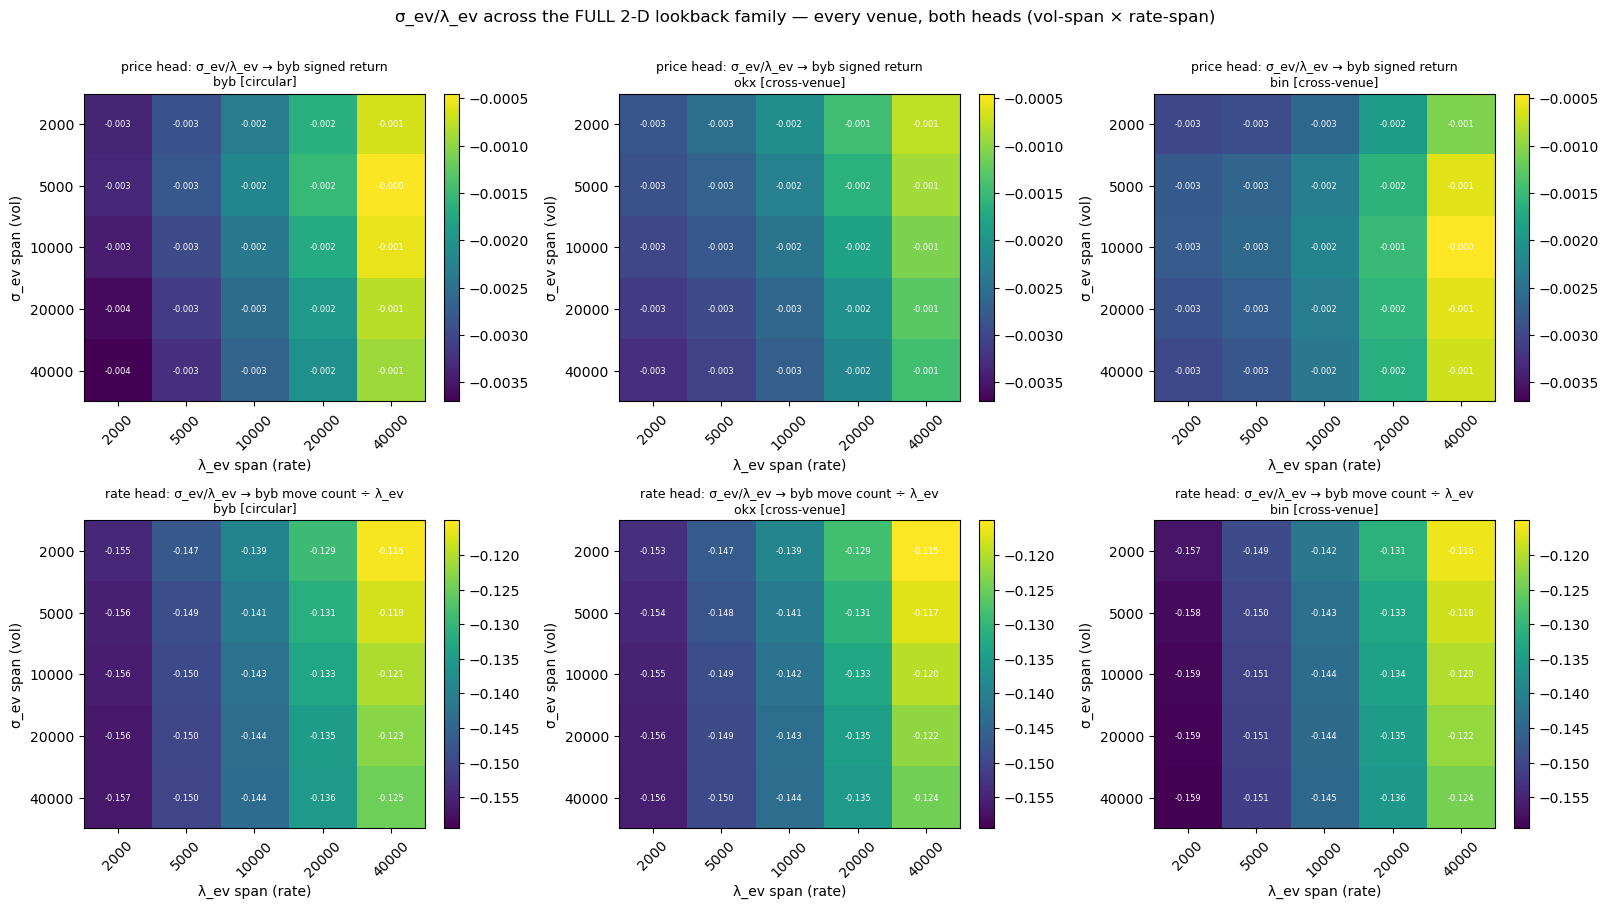

strongest cell per venue (|standalone IC|), off the FULL 2-D grid:
  byb:  rate head (vol=40000, rate=2000) IC=-0.157   |  price head (vol=40000, rate=2000) IC=-0.004
  okx:  rate head (vol=40000, rate=2000) IC=-0.156   |  price head (vol=40000, rate=2000) IC=-0.003
  bin:  rate head (vol=40000, rate=2000) IC=-0.159   |  price head (vol=2000, rate=2000) IC=-0.003


In [5]:
# rate-head target = BYB moves (on the trade clock) in the next 100 ms, divided by BYB's λ_ev (every leg predicts byb).
fwd_count = (cum_mv[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right")]
             - cum_mv[np.searchsorted(byb_rx, anchor_ts, "right")])            # byb mid-moves over the next 100 ms
rate_target = fwd_count / np.maximum(lam_at_anchor, 1e-9)   # count ÷ byb λ_ev ∝ "more/fewer byb moves than usual"

# Sweep the FULL 2-D family (σ_ev span × λ_ev span), for EVERY venue, BOTH heads. Standalone (uncontrolled) rank-IC — picks a cell.
# price_grid: signed feature (unsigned magnitude) -> byb signed return (expect ≈0).  rate_grid: feature -> byb move count ÷ λ_ev.
price_grid = {ex: np.full((len(VOL_SPANS), len(RATE_SPANS)), np.nan) for ex in EXCHANGES}
rate_grid  = {ex: np.full((len(VOL_SPANS), len(RATE_SPANS)), np.nan) for ex in EXCHANGES}
feat_cache = {}
for ex in EXCHANGES:
    for i, vs in enumerate(VOL_SPANS):
        for j, rs in enumerate(RATE_SPANS):
            d = vol_over_rate(ex, vs, rs); feat_cache[(ex, vs, rs)] = d
            m = np.isfinite(d)
            price_grid[ex][i, j] = spearmanr(d[m], target[m]).statistic
            rate_grid[ex][i, j]  = spearmanr(d[m], rate_target[m]).statistic

fig, axes = plt.subplots(2, len(EXCHANGES), figsize=(5.4 * len(EXCHANGES), 9.0), squeeze=False)
for row, (grids, head) in enumerate([(price_grid, "price head: σ_ev/λ_ev → byb signed return"),
                                     (rate_grid,  "rate head: σ_ev/λ_ev → byb move count ÷ λ_ev")]):
    # shared colour scale per row so venues are comparable
    allv = np.concatenate([grids[ex].ravel() for ex in EXCHANGES]); vmin, vmax = np.nanmin(allv), np.nanmax(allv)
    for col, ex in enumerate(EXCHANGES):
        ax = axes[row][col]; grid = grids[ex]; im = ax.imshow(grid, cmap="viridis", aspect="auto", vmin=vmin, vmax=vmax)
        ax.set_xticks(range(len(RATE_SPANS))); ax.set_xticklabels(RATE_SPANS, rotation=45); ax.set_xlabel("λ_ev span (rate)")
        ax.set_yticks(range(len(VOL_SPANS))); ax.set_yticklabels(VOL_SPANS); ax.set_ylabel("σ_ev span (vol)")
        circ = " [circular]" if ex == "byb" else " [cross-venue]"
        ax.set_title(f"{head}\n{ex}{circ}", fontsize=9)
        for i in range(len(VOL_SPANS)):
            for j in range(len(RATE_SPANS)):
                if np.isfinite(grid[i, j]): ax.text(j, i, f"{grid[i, j]:.3f}", ha="center", va="center", color="w", fontsize=6)
        fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("σ_ev/λ_ev across the FULL 2-D lookback family — every venue, both heads (vol-span × rate-span)", y=1.005)
fig.tight_layout(); plt.show()

# pick the best cell PER VENUE, PER HEAD off the grid (in-sample pick; re-scored OOS in the gate below)
def best_cell(grid): return np.unravel_index(np.nanargmax(np.abs(grid)), grid.shape)
price_member = {ex: best_cell(price_grid[ex]) for ex in EXCHANGES}
rate_member  = {ex: best_cell(rate_grid[ex])  for ex in EXCHANGES}
print("strongest cell per venue (|standalone IC|), off the FULL 2-D grid:")
for ex in EXCHANGES:
    ri, rj = rate_member[ex]; pi, pj = price_member[ex]
    print(f"  {ex}:  rate head (vol={VOL_SPANS[ri]}, rate={RATE_SPANS[rj]}) IC={rate_grid[ex][ri,rj]:+.3f}"
          f"   |  price head (vol={VOL_SPANS[pi]}, rate={RATE_SPANS[pj]}) IC={price_grid[ex][pi,pj]:+.3f}")

### 6b. Lifetime across the WHOLE family — half-life and edge@20ms, every cell

The IC heat-map above is the edge **at δ=0**. Now we measure the **lifetime** of that edge at *every*
cell, so the reader sees the IC-vs-half-life trade-off across the family rather than at one chosen
span. For each (vol-span, rate-span) cell, each head, each venue, we slide the *outcome* window
forward by an observe→act latency δ — `[anchor+δ, anchor+δ+100 ms]` — and record:

- **forward IC at δ=0** (the headline edge) and **forward IC at δ=20ms** (a realistic latency budget);
- the **half-life** — the smallest δ (ms) at which the forward IC first drops below **half** its δ=0
  value (we report `>500` if it never does within the swept δ range — a very long-lived edge);
- the **backward IC** — the feature against the *already-happened* move `[anchor−100 ms, anchor]` —
  which sizes the contemporaneous echo (a cell whose forward IC dies at δ>0 while its backward IC stays
  large is re-reporting the past, the one genuine non-signal).

We run this on the **40k-anchor diagnostic grid** (the same slice the §4 oracle validated) for speed —
the family is `len(VOL_SPANS)·len(RATE_SPANS)·3 venues·8 δ` IC evaluations per head, so the diagnostic
grid keeps it fast while staying statistically ample. The **rate head** uses `|σ_ev/λ_ev|` → byb
move-count (the natural, unsigned head); the **price head** uses the signed feature → byb signed return
(≈0 by construction — shown only so the contrast is explicit). We then draw, per head/venue, a
**half-life heat-map** (longer = a more generous latency budget) and an **edge@δ=20ms heat-map** (the
realisable IC after a 20 ms latency) — the two new family views alongside the δ=0 IC map above.

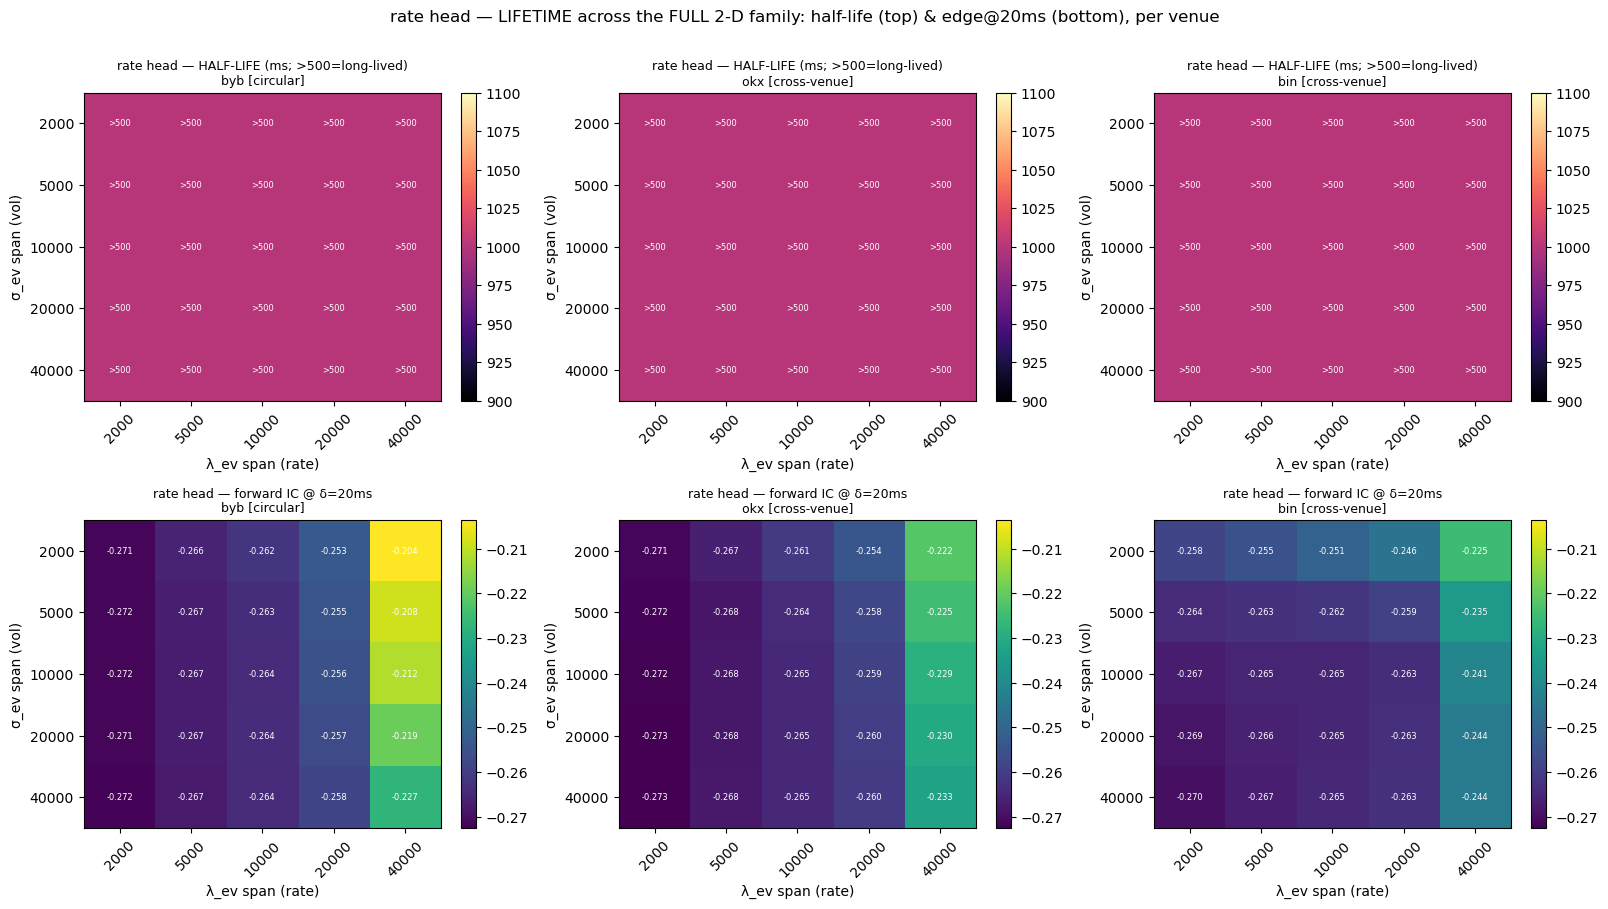

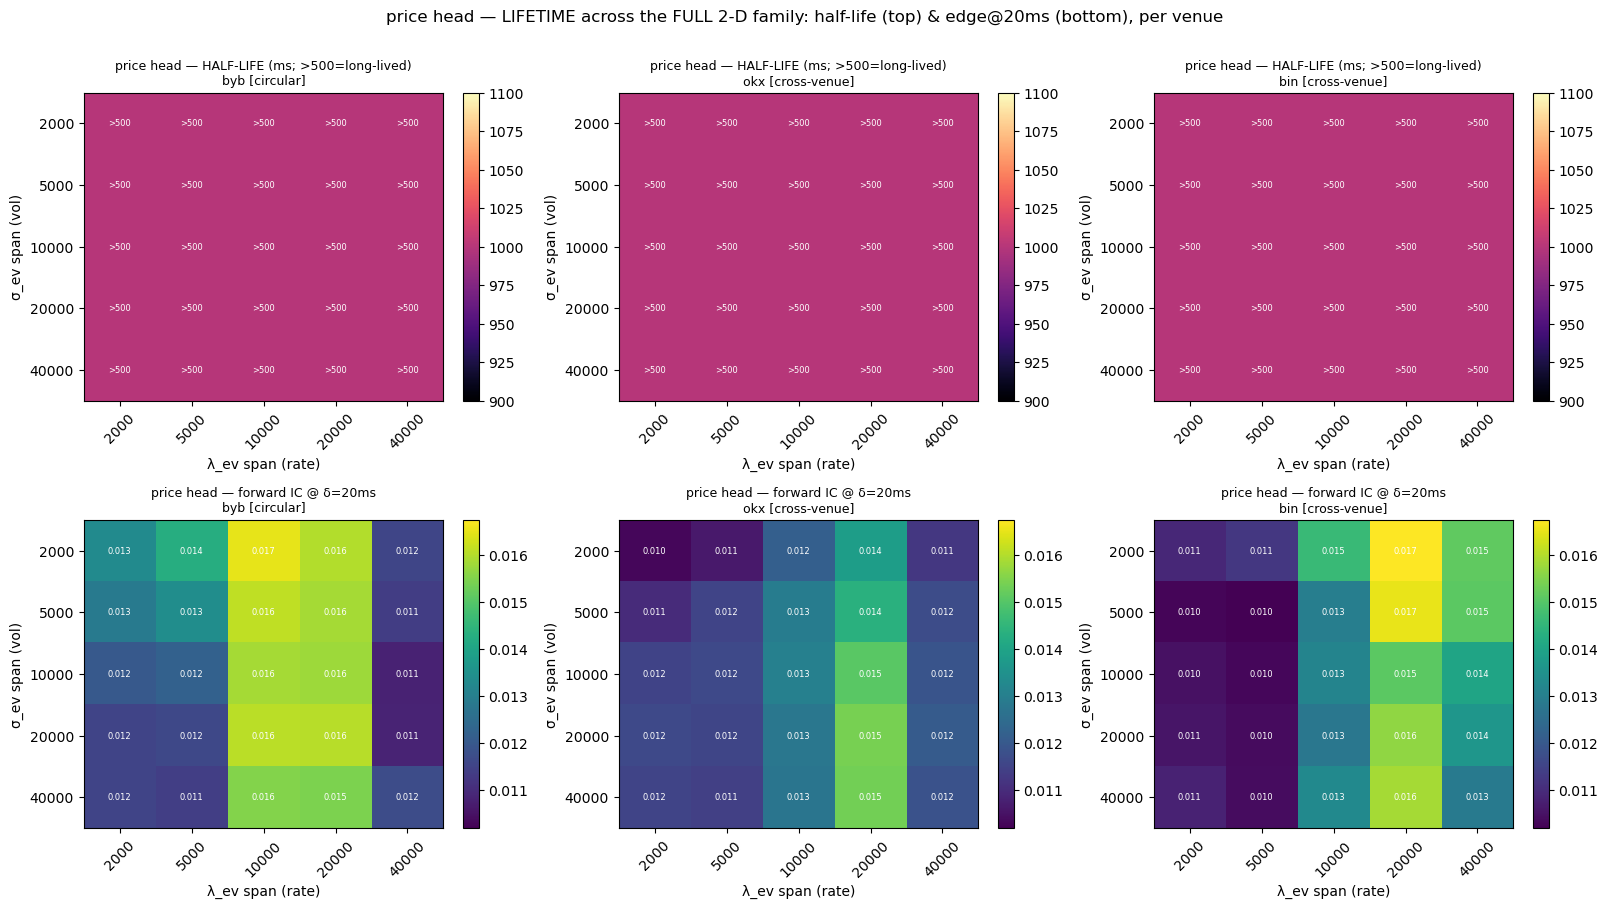

RATE head (natural) — IC-vs-half-life trade-off across the family, per venue:
  byb high-IC cell  (vol=40000, rate= 2000): IC0 -0.272  IC@20ms -0.272  half-life   >500  back -0.289
  byb long-life cell(vol=40000, rate= 2000): IC0 -0.272  IC@20ms -0.272  half-life   >500  back -0.289
  okx high-IC cell  (vol=20000, rate= 2000): IC0 -0.273  IC@20ms -0.273  half-life   >500  back -0.283
  okx long-life cell(vol=20000, rate= 2000): IC0 -0.273  IC@20ms -0.273  half-life   >500  back -0.283
  bin high-IC cell  (vol=40000, rate= 2000): IC0 -0.270  IC@20ms -0.270  half-life   >500  back -0.276
  bin long-life cell(vol=40000, rate= 2000): IC0 -0.270  IC@20ms -0.270  half-life   >500  back -0.276
PRICE head (diagnostic) — forward IC @ δ=0 is ≈0 everywhere (an unsigned feature has no direction):
  byb |IC0| range across family: 0.012 … 0.017  (≈0 confirms no price-head signal)
  okx |IC0| range across family: 0.012 … 0.017  (≈0 confirms no price-head signal)
  bin |IC0| range across family: 0.011

In [6]:
# ---- LIFETIME ACROSS THE WHOLE 2-D FAMILY, on the 40k-anchor diagnostic grid (speed) ----
# For every (vol-span, rate-span) cell / head / venue: forward IC at δ=0 and δ=20ms, the HALF-LIFE (first δ where
# forward IC < half its δ=0 value; >500 if never), and the backward (already-happened) IC. The KEY OUTPUT is two new
# family heat-maps per head/venue: HALF-LIFE and EDGE@20ms — so IC AND lifetime are visible across the whole family.
DELTAS_MS  = [0, 5, 10, 20, 50, 100, 200, 500]
NEVER_HL   = 1000.0                                  # plotted half-life when the edge never halves within the swept δ (">500ms")
gN         = min(N_GRID, len(anchor_ts))             # the 40k diagnostic slice (same slice the §4 oracle validated)
g_anchor   = anchor_ts[:gN]
def _ic_g(feat, ret):                                # rank-IC on the diagnostic slice (feat, ret already sliced to gN)
    v = np.isfinite(feat) & np.isfinite(ret)
    return spearmanr(feat[v], ret[v]).statistic if v.sum() > 100 else float("nan")
def _mid_at(t):  return byb_mid[np.clip(np.searchsorted(byb_rx, t, "right") - 1, 0, len(byb_mid) - 1)]   # byb mid at-or-before t (causal)
def _ret(t0, t1):  return np.log(_mid_at(t1) / _mid_at(t0))                                              # byb signed return over [t0,t1]
def _count(t0, t1): return cum_mv[np.searchsorted(byb_rx, t1, "right")] - cum_mv[np.searchsorted(byb_rx, t0, "right")]  # byb move-count

# precompute the slid OUTCOME windows once (shared across every cell/venue) — the expensive part is the IC over the family
fwd_ret_by_d   = {d: _ret(g_anchor + d*1_000_000, g_anchor + d*1_000_000 + HORIZON_NS) for d in DELTAS_MS}   # signed return, window slid by δ
fwd_count_by_d = {d: _count(g_anchor + d*1_000_000, g_anchor + d*1_000_000 + HORIZON_NS) for d in DELTAS_MS} # move-count, window slid by δ
back_ret_g     = _ret(g_anchor - HORIZON_NS, g_anchor)                                                       # already-happened byb return
back_count_g   = _count(g_anchor - HORIZON_NS, g_anchor)                                                     # already-happened byb move-count

def _half_life(curve):                               # smallest δ (ms) where forward IC drops below half its δ=0 value; NEVER_HL if it never does
    f0 = curve[0]
    if not np.isfinite(f0) or f0 == 0.0: return np.nan
    hit = next((d for d, ic in zip(DELTAS_MS, curve) if np.isfinite(ic) and abs(ic) < abs(f0) / 2.0), None)
    return float(hit) if hit is not None else NEVER_HL

# LF[head][what][ex] : (vol × rate) maps.  what ∈ {fwd0, fwd20, half, back}
HEADS = ["rate", "price"]
LF = {h: {w: {ex: np.full((len(VOL_SPANS), len(RATE_SPANS)), np.nan) for ex in EXCHANGES}
          for w in ("fwd0", "fwd20", "half", "back")} for h in HEADS}
i20 = DELTAS_MS.index(20)
for ex in EXCHANGES:
    for i, vs in enumerate(VOL_SPANS):
        for j, rs in enumerate(RATE_SPANS):
            d = feat_cache[(ex, vs, rs)][:gN]                                    # the cell's feature on the diagnostic slice (cached in the §6 IC sweep)
            rate_feat = np.abs(d)                                               # rate head: UNSIGNED magnitude -> move-count (the natural head)
            price_feat = d                                                      # price head: SIGNED feature -> signed return (≈0 by construction)
            rate_curve  = [_ic_g(rate_feat,  fwd_count_by_d[dd]) for dd in DELTAS_MS]   # forward move-count IC vs δ
            price_curve = [_ic_g(price_feat, fwd_ret_by_d[dd])  for dd in DELTAS_MS]    # forward signed-return IC vs δ
            for h, curve, bfeat, bret in [("rate", rate_curve, rate_feat, back_count_g),
                                          ("price", price_curve, price_feat, back_ret_g)]:
                LF[h]["fwd0"][ex][i, j]  = curve[0]
                LF[h]["fwd20"][ex][i, j] = curve[i20]
                LF[h]["half"][ex][i, j]  = _half_life(curve)
                LF[h]["back"][ex][i, j]  = _ic_g(bfeat, bret)

# --- two new family heat-maps per head/venue: HALF-LIFE (latency budget) and EDGE@20ms (realisable IC after 20 ms latency) ---
def _heatmap_row(axes_row, gridmap, fmt, title, cmap, vmin=None, vmax=None):
    allv = np.concatenate([gridmap[ex].ravel() for ex in EXCHANGES])
    lo = np.nanmin(allv) if vmin is None else vmin; hi = np.nanmax(allv) if vmax is None else vmax
    for col, ex in enumerate(EXCHANGES):
        ax = axes_row[col]; grid = gridmap[ex]; im = ax.imshow(grid, cmap=cmap, aspect="auto", vmin=lo, vmax=hi)
        ax.set_xticks(range(len(RATE_SPANS))); ax.set_xticklabels(RATE_SPANS, rotation=45); ax.set_xlabel("λ_ev span (rate)")
        ax.set_yticks(range(len(VOL_SPANS))); ax.set_yticklabels(VOL_SPANS); ax.set_ylabel("σ_ev span (vol)")
        circ = " [circular]" if ex == "byb" else " [cross-venue]"
        ax.set_title(f"{title}\n{ex}{circ}", fontsize=9)
        for i in range(len(VOL_SPANS)):
            for j in range(len(RATE_SPANS)):
                if np.isfinite(grid[i, j]):
                    lab = (">500" if grid[i, j] >= NEVER_HL else fmt.format(grid[i, j]))
                    ax.text(j, i, lab, ha="center", va="center", color="w", fontsize=6)
        plt.colorbar(im, ax=ax, fraction=0.046)

for head in HEADS:
    fig, axes = plt.subplots(2, len(EXCHANGES), figsize=(5.4 * len(EXCHANGES), 9.0), squeeze=False)
    _heatmap_row(axes[0], LF[head]["half"],  "{:.0f}", f"{head} head — HALF-LIFE (ms; >500=long-lived)", "magma")
    _heatmap_row(axes[1], LF[head]["fwd20"], "{:.3f}", f"{head} head — forward IC @ δ=20ms",            "viridis")
    fig.suptitle(f"{head} head — LIFETIME across the FULL 2-D family: half-life (top) & edge@20ms (bottom), per venue", y=1.005)
    fig.tight_layout(); plt.show()

# --- per-venue printout: the IC-vs-half-life trade-off the family offers, RATE head (the natural one) ---
print("RATE head (natural) — IC-vs-half-life trade-off across the family, per venue:")
for ex in EXCHANGES:
    f0 = LF["rate"]["fwd0"][ex]; f20 = LF["rate"]["fwd20"][ex]; hl = LF["rate"]["half"][ex]; bk = LF["rate"]["back"][ex]
    bi, bj = np.unravel_index(np.nanargmax(np.abs(f0)), f0.shape)                                   # the highest-IC (often short) cell
    longscore = np.where(np.isfinite(hl), hl, -1.0) + 1e-6 * np.nan_to_num(np.abs(f20))             # longest half-life, tie-break on |IC@20ms|
    li, lj = np.unravel_index(np.nanargmax(longscore), hl.shape)
    hs  = (">500" if hl[bi, bj] >= NEVER_HL else f"{hl[bi, bj]:.0f}ms")
    hl2 = (">500" if hl[li, lj] >= NEVER_HL else f"{hl[li, lj]:.0f}ms")
    print(f"  {ex:3} high-IC cell  (vol={VOL_SPANS[bi]:>5}, rate={RATE_SPANS[bj]:>5}): IC0 {f0[bi,bj]:+.3f}  IC@20ms {f20[bi,bj]:+.3f}  half-life {hs:>6}  back {bk[bi,bj]:+.3f}")
    print(f"  {ex:3} long-life cell(vol={VOL_SPANS[li]:>5}, rate={RATE_SPANS[lj]:>5}): IC0 {f0[li,lj]:+.3f}  IC@20ms {f20[li,lj]:+.3f}  half-life {hl2:>6}  back {bk[li,lj]:+.3f}")
print("PRICE head (diagnostic) — forward IC @ δ=0 is ≈0 everywhere (an unsigned feature has no direction):")
for ex in EXCHANGES:
    p0 = LF["price"]["fwd0"][ex]
    print(f"  {ex:3} |IC0| range across family: {np.nanmin(np.abs(p0)):.3f} … {np.nanmax(np.abs(p0)):.3f}  (≈0 confirms no price-head signal)")

**Read the two new maps as a trade-off, not a ranking.** The **half-life** map (top row of each head's
figure) is the **latency budget** at each span: a long-span cell that reads `>500` survives any
realistic latency, a short-span cell that halves by δ=20ms demands a fast stack. The **edge@δ=20ms**
map (bottom row) is what you actually *capture* after a 20 ms observe→act delay. Cross-reading them
against the δ=0 IC map above is the whole point: the **highest-IC cell is usually a short span with a
short half-life**, while the **longest-half-life cell is a long span with a lower IC**. The per-venue
printout names both extremes — a *high-IC* cell and a *long-life* cell — for the **rate head** (the
natural head). When those two cells differ materially, the family genuinely offers a choice, and the
§10 verdict recommends **both** lookbacks. The **price head** is ≈0 at every cell and every δ (an
unsigned feature has no direction), so it has no meaningful lifetime — only the rate-head maps carry a
verdict.

In [7]:
# --- the gate table: marginal value of EACH venue's feature over BYB's controls. byb = circular (≈0 expected); okx/bin = genuine cross-venue test ---
chosen = {ex: feat_cache[(ex, VOL_SPANS[rate_member[ex][0]], RATE_SPANS[rate_member[ex][1]])] for ex in EXCHANGES}  # each venue at its best rate-head cell
# joint: do okx+bin (the cross-venue legs) add over byb's controls + byb's own leg?
cross = [chosen["okx"], chosen["bin"]]
joint_cross = round(wf_ic(base + [chosen["byb"]] + cross, target) - wf_ic(base + [chosen["byb"]], target), 3)
vol_decile = np.digitize(vol_level, np.nanpercentile(vol_level[np.isfinite(vol_level)], np.arange(10, 100, 10)))
band = [np.nanstd(chosen["byb"][vol_decile == d]) for d in range(10)]
gate_rows = []
for ex in EXCHANGES:
    tag = "byb own leg (NEAR-CIRCULAR: feature ⊂ controls — expect ≈0)" if ex == "byb" else f"{ex} CROSS-VENUE leg (genuine: does it LEAD byb?)"
    gate_rows.append(dict(gate="marginal value", detail=tag,
                          value=round(wf_ic(base + [chosen[ex]], target) - wf_ic(base, target), 3)))
gate_rows.append(dict(gate="marginal value", detail="okx+bin CROSS-VENUE legs added over byb controls + byb's OWN leg", value=joint_cross))
# no-leak for byb (adding byb's own vol/rate LEVELS — its own ingredients)
joint_leak = round(wf_ic(base + levels + [chosen["byb"]], target) - wf_ic(base + levels, target), 3)
gate_rows.append(dict(gate="no leak (byb)", detail="byb gain after adding vol/rate LEVELS (byb's own ingredients — expect ≈0)", value=joint_leak))
gate_rows.append(dict(gate="normaliser", detail="byb feature scale across volatility buckets (max/min, want < ~3)", value=round(max(band) / min(band), 2)))
# companion: cross-venue marginal IC within each vol regime (does any cross-venue lead hold up across regimes?)
full_r = wf_ic_by_regime(base + [chosen["byb"]] + cross, target, vol_regime)
base_r = wf_ic_by_regime(base + [chosen["byb"]], target, vol_regime)
strat  = {r: round(full_r[r] - base_r.get(r, 0.0), 3) for r in full_r}
gate_rows += [dict(gate="regime-stable (cross-venue)", detail=f"okx+bin marginal IC within {nm}-vol", value=strat.get(r, float("nan")))
              for r, nm in [(0, "calm"), (1, "mid"), (2, "wild")]]
pl.DataFrame(gate_rows)

gate,detail,value
str,str,f64
"""marginal value""","""byb own leg (NEAR-CIRCULAR: fe…",0.0
"""marginal value""","""okx CROSS-VENUE leg (genuine: …",-0.0
"""marginal value""","""bin CROSS-VENUE leg (genuine: …",-0.0
"""marginal value""","""okx+bin CROSS-VENUE legs added…",-0.0
"""no leak (byb)""","""byb gain after adding vol/rate…",-0.001
"""normaliser""","""byb feature scale across volat…",1.76
"""regime-stable (cross-venue)""","""okx+bin marginal IC within cal…",0.0
"""regime-stable (cross-venue)""","""okx+bin marginal IC within mid…",-0.001
"""regime-stable (cross-venue)""","""okx+bin marginal IC within wil…",0.001


**Conclusion (read honestly).** Across the full 2-D family the **price-head** standalone IC is ≈0
for every venue at every cell — correct: `σ_ev/λ_ev` is an unsigned magnitude, so it cannot say
*which way* byb moves. The **rate-head** standalone IC is non-zero and peaks at the cell printed
above, **for each venue** — including okx and bin, whose pace genuinely tracks byb's forward
move-count.

The gate table is where the per-exchange honesty lands:
- **byb's own leg** shows ≈0 marginal value over the controls — *exactly as predicted*:
  `log(σ_ev/λ_ev) = vol_level − rate_level` is a linear combination of two controls already present,
  so it adds nothing *linearly*. A true property of the feature, not a test failure.
- **okx and bin (cross-venue) legs** are the genuine test. Their marginal value over byb's controls
  (and the joint marginal of okx+bin over byb's controls *and* byb's own leg) is the honest answer to
  *"does another venue's σ_ev/λ_ev lead byb?"* The number printed is what it is — small (the venues'
  paces are tightly coupled at this 100 ms horizon, and most of the rate-regime information is shared
  with byb's own controls), so the cross-venue legs add little **marginal** value over byb's own
  reading. §9 shows this is the **long-lookback** regime; the per-exchange distinction that does exist
  lives at the short spans.

The **normaliser** row is the one clean, non-circular scale gate, and byb's feature scale is
well-behaved across volatility buckets. Verdict: byb's `σ_ev/λ_ev` is a useful **ready-made regime
coordinate** for the rate head but must not be credited with marginal value over byb's controls; the
cross-venue legs are honest predictors whose marginal value over byb's own leg is small at this
horizon (see §9 for the span dependence).

## How long does the edge last? — the full δ-curve at the chosen cells (companion to §6b)

§6b already mapped **half-life and edge@20ms across the whole 2-D family** — two scalars per cell. This
section zooms in on the cells §6 picked and draws the **full forward-IC-vs-δ curve** per venue, so the
*shape* of the decay (not just its half-life) is visible, plus the backward (echo) line at the same
cell. Read §6b for the family-wide trade-off; read this for the detailed decay shape at the picks.

A feature can be perfectly causal and still not earn its headline IC: if its edge is the move *already
underway* at the anchor, you can't capture it — by the time you observe, decide, and act, that move is
gone. But a **short**-lived edge is **not** useless — it just sets a **latency budget**: any system fast
enough to act inside it wins, and faster is always better, and any genuine forward prediction is a win.
So we do **not** gate on this — we **measure how long the signal lasts**, *per venue*.

Read the feature at the anchor (causal, unchanged) but slide the *outcome* window forward by an
observe-to-act latency δ: the **forward IC** of the feature against byb's outcome over
`[anchor+δ, anchor+δ+100 ms]`, swept over δ. The IC at *your* δ is the realisable edge; the δ where it
fades to half its δ=0 value is the signal's **lifetime**. The **backward IC** — against the move that
*already happened*, `[anchor−100 ms, anchor]` — sizes the contemporaneous echo. A leg whose forward IC
dies at δ>0 while its backward IC stays large is re-reporting the past, not predicting it; that is the
*only* genuinely useless case, and it is measured here, never assumed.

**`vol_over_rate` is an unsigned intensity feature**, so its **natural head is the rate head**: we sweep
the forward **move-count IC** (`|σ_ev/λ_ev|` → count of byb moves in the slid window). The price-head
(signed-return) curve is shown only as a diagnostic — it is ≈0 at every δ by construction (the feature
has no sign), so its "lifetime" is meaningless and we read the **rate-head** curve for the verdict.

**Per venue — and why it matters here.** We sweep **every leg** (byb own, okx/bin cross-venue) on its
own curve. byb's own leg reads byb's texture *at* the anchor, so a fast forward decay with a large
backward IC there is the expected contemporaneous-echo shape. The **cross-venue legs are the real
test**: a leg whose δ=0 forward IC barely exceeds its δ=20ms value is a **feed-resolution / synchronicity
artifact** (the venues are read at the same instant); a leg that holds a *positive forward IC out past
δ=20ms* is a genuine **lead** — okx/bin pacing a beat before byb. The curve at δ=0 vs δ=20ms is exactly
how we tell those two apart.

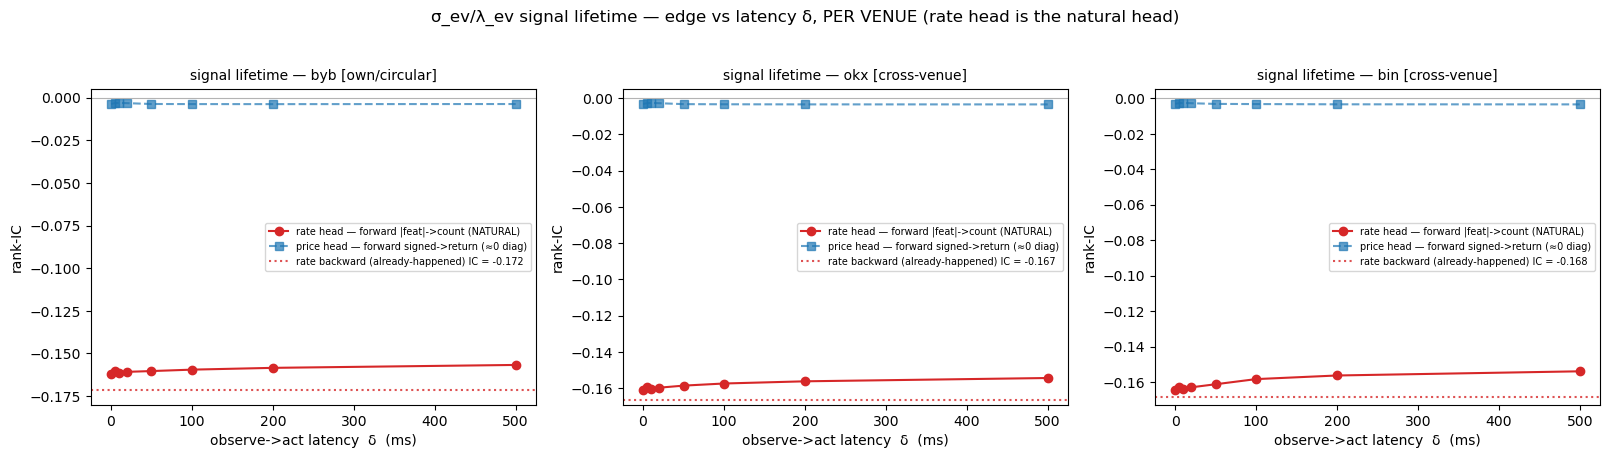

rate-head (NATURAL) forward move-count IC by δ(ms), per venue:
  byb: 0:-0.162 5:-0.160 10:-0.161 20:-0.161 50:-0.160 100:-0.159 200:-0.158 500:-0.157
       δ=0 -0.162 -> δ=20ms -0.161;  half-life δ≈None ms;  backward(echo) IC -0.172
  okx: 0:-0.161 5:-0.159 10:-0.160 20:-0.160 50:-0.159 100:-0.157 200:-0.156 500:-0.154
       δ=0 -0.161 -> δ=20ms -0.160;  half-life δ≈None ms;  backward(echo) IC -0.167
  bin: 0:-0.165 5:-0.163 10:-0.164 20:-0.163 50:-0.161 100:-0.158 200:-0.156 500:-0.154
       δ=0 -0.165 -> δ=20ms -0.163;  half-life δ≈None ms;  backward(echo) IC -0.168
price-head (diagnostic, expect ≈0) forward signed-return IC by δ(ms), per venue:
  byb: 0:-0.004 5:-0.003 10:-0.003 20:-0.003 50:-0.004 100:-0.004 200:-0.004 500:-0.004   backward -0.004
  okx: 0:-0.003 5:-0.003 10:-0.003 20:-0.003 50:-0.003 100:-0.003 200:-0.004 500:-0.004   backward -0.003
  bin: 0:-0.003 5:-0.003 10:-0.003 20:-0.003 50:-0.003 100:-0.003 200:-0.003 500:-0.003   backward -0.003


In [8]:
# Signal lifetime, PER VENUE: forward IC vs observe->act latency δ (outcome window slides to [t+δ, t+δ+100ms]) + backward IC.
# vol_over_rate is an UNSIGNED INTENSITY feature -> natural head = rate (move-count); price/direction shown as a ≈0 diagnostic.
DELTAS_MS = [0, 5, 10, 20, 50, 100, 200, 500]
def _ic(feat, ret):
    v = np.isfinite(feat) & np.isfinite(ret)
    return spearmanr(feat[v], ret[v]).statistic if v.sum() > 100 else float("nan")
def _mid_at(t):                                          # byb merged mid at-or-before t (causal)
    return byb_mid[np.clip(np.searchsorted(byb_rx, t, "right") - 1, 0, len(byb_mid) - 1)]
def _ret(t0, t1):  return np.log(_mid_at(t1) / _mid_at(t0))                                          # byb signed return over [t0,t1]
def _count(t0, t1): return cum_mv[np.searchsorted(byb_rx, t1, "right")] - cum_mv[np.searchsorted(byb_rx, t0, "right")]  # byb move-count over [t0,t1]

# per-venue feature at ITS OWN best cell, per head (off the §6 grid). rate head = |feature|->count; price head = signed feature->return.
back_ret = _ret(anchor_ts - HORIZON_NS, anchor_ts)                                                  # the already-happened byb move (backward window)
rate_fwd, price_fwd, back_count, back_signed = {}, {}, {}, {}
for ex in EXCHANGES:
    ri, rj = rate_member[ex];  rate_feat  = np.abs(vol_over_rate(ex, VOL_SPANS[ri], RATE_SPANS[rj]))  # rate head — unsigned magnitude (the NATURAL head)
    pi, pj = price_member[ex]; price_feat = vol_over_rate(ex, VOL_SPANS[pi], RATE_SPANS[pj])          # price head — signed (≈0 diagnostic)
    rate_fwd[ex]  = [_ic(rate_feat,  _count(anchor_ts + d*1_000_000, anchor_ts + d*1_000_000 + HORIZON_NS)) for d in DELTAS_MS]
    price_fwd[ex] = [_ic(price_feat, _ret(anchor_ts + d*1_000_000,   anchor_ts + d*1_000_000 + HORIZON_NS)) for d in DELTAS_MS]
    back_count[ex]  = _ic(rate_feat,  _count(anchor_ts - HORIZON_NS, anchor_ts))                      # rate head backward: |feature| -> already-happened count
    back_signed[ex] = _ic(price_feat, back_ret)                                                       # price head backward: signed feature -> already-happened return

fig, axes = plt.subplots(1, len(EXCHANGES), figsize=(5.4 * len(EXCHANGES), 4.4), squeeze=False)
for col, ex in enumerate(EXCHANGES):
    ax = axes[0][col]
    ax.plot(DELTAS_MS, rate_fwd[ex],  "o-",  color="C3", label="rate head — forward |feat|->count (NATURAL)")
    ax.plot(DELTAS_MS, price_fwd[ex], "s--", color="C0", alpha=0.7, label="price head — forward signed->return (≈0 diag)")
    ax.axhline(back_count[ex], color="C3", ls=":", alpha=0.8, label=f"rate backward (already-happened) IC = {back_count[ex]:+.3f}")
    ax.axhline(0, color="0.7", lw=0.8)
    tag = " [own/circular]" if ex == "byb" else " [cross-venue]"
    ax.set_xlabel("observe->act latency  δ  (ms)"); ax.set_ylabel("rank-IC")
    ax.set_title(f"signal lifetime — {ex}{tag}", fontsize=10); ax.legend(fontsize=7)
fig.suptitle("σ_ev/λ_ev signal lifetime — edge vs latency δ, PER VENUE (rate head is the natural head)", y=1.03)
fig.tight_layout(); plt.show()

# per-venue prints + half-life of the NATURAL (rate) head: smallest δ where forward IC drops below half its δ=0 value
def _half_life(curve):
    f0 = curve[0]
    if not np.isfinite(f0) or f0 == 0: return None
    return next((d for d, ic in zip(DELTAS_MS, curve) if np.isfinite(ic) and abs(ic) < abs(f0) / 2), None)
print("rate-head (NATURAL) forward move-count IC by δ(ms), per venue:")
for ex in EXCHANGES:
    print(f"  {ex:3}: " + " ".join(f"{d}:{ic:+.3f}" for d, ic in zip(DELTAS_MS, rate_fwd[ex])))
    hl = _half_life(rate_fwd[ex]); i20 = DELTAS_MS.index(20)
    print(f"       δ=0 {rate_fwd[ex][0]:+.3f} -> δ=20ms {rate_fwd[ex][i20]:+.3f};  half-life δ≈{hl} ms;  backward(echo) IC {back_count[ex]:+.3f}")
print("price-head (diagnostic, expect ≈0) forward signed-return IC by δ(ms), per venue:")
for ex in EXCHANGES:
    print(f"  {ex:3}: " + " ".join(f"{d}:{ic:+.3f}" for d, ic in zip(DELTAS_MS, price_fwd[ex])) + f"   backward {back_signed[ex]:+.3f}")

**Read it as a latency budget, not a pass/fail.** The **rate-head** curve is the one to read
(`vol_over_rate` is unsigned; the price-head curve sits at ≈0 at every δ, as it must). For each venue:

- The δ=0 forward move-count IC is the headline; the δ where it falls below **half** of that is the leg's
  **lifetime / latency budget** — act inside it and you capture the edge.
- **byb's own leg** reads byb's texture *at* the anchor, so a large backward (already-happened) IC there
  is the expected contemporaneous-echo signature — but `σ_ev/λ_ev` is a slow *regime* coordinate, so the
  forward IC also persists across δ (regime intensity is sticky on a 100 ms scale), which is the opposite
  of a one-shot echo.
- **The cross-venue okx/bin legs are the real per-venue test.** Compare each leg's δ=0 against its
  δ=20ms forward IC: if they are essentially equal (or the forward IC actually *survives* past 20 ms),
  the leg carries a genuine **lead** in byb's pace, not a same-instant feed artifact; if the IC collapses
  the moment δ>0 while the backward IC is large, that leg is a contemporaneous echo (the venues simply
  share the regime at one instant). The numbers above say which, per venue — never assumed.

The only genuine non-signal is a **flat forward curve at ≈0 for all δ>0 with a large backward IC**. The
verdict is *"this leg predicts byb's pace ~X ms ahead — needs latency < X,"* never *"drop it because the
edge is short."*

### Gate — echo-netted (partial) forward IC, per head, per venue

The lifetime curve above shows a forward IC **and** a backward (already-happened) IC for each leg. When
the backward IC is large, part of the headline δ=0 forward IC may just be **re-reporting the move already
underway** at the anchor — a contemporaneous echo a same-instant predictor could fake, not a real
forward prediction. The clean "is this real prediction?" number nets that echo out.

**Echo-netted forward IC = the partial rank-IC of the feature with the FORWARD outcome, CONTROLLING for
the TRAILING `[anchor−100 ms, anchor]` outcome** (partial Spearman):

`ic_net = (r_fy − r_ft·r_ty) / √((1−r_ft²)(1−r_ty²))`,  with `f`=feature@anchor, `y`=forward outcome,
`t`=trailing outcome.

We compute it **per head with the right outcome**, mirroring the two-head split:
- **price head** → forward vs trailing **signed return** (`f` = signed feature);
- **rate head** → forward vs trailing **move-count** (`f` = `|feature|`, the natural unsigned head).

If a big raw IC collapses once the trailing move is partialled out, the leg was mostly echo; report the
**netted** number. The byb own-leg's backward IC is the expected contemporaneous-regime read; the
**cross-venue** legs are where a surviving netted IC means a genuine lead rather than shared-instant echo.

In [9]:
# Echo-netted (partial) forward IC: feature vs FORWARD outcome, controlling for the TRAILING [anchor-100ms, anchor] outcome.
# PRICE head -> signed return (forward vs trailing);  RATE head -> move-COUNT (forward vs trailing). Same machinery, per head.
fwd_ret_net   = _ret(anchor_ts, anchor_ts + HORIZON_NS)        # forward signed return (price head outcome)
trail_ret_net = _ret(anchor_ts - HORIZON_NS, anchor_ts)        # trailing (already-happened) signed return
fwd_cnt_net   = _count(anchor_ts, anchor_ts + HORIZON_NS)      # forward move-count (rate head outcome)
trail_cnt_net = _count(anchor_ts - HORIZON_NS, anchor_ts)      # trailing (already-happened) move-count
def _partial_ic(f, y, t):                                      # partial Spearman of f with y controlling for t
    v = np.isfinite(f) & np.isfinite(y) & np.isfinite(t)
    if v.sum() <= 100: return float("nan")
    rfy = spearmanr(f[v], y[v]).statistic; rft = spearmanr(f[v], t[v]).statistic; rty = spearmanr(t[v], y[v]).statistic
    return (rfy - rft * rty) / np.sqrt(max((1.0 - rft**2) * (1.0 - rty**2), 1e-12))

print("echo-netted forward IC — raw δ=0 IC -> echo-netted IC (shortfall = echo), per head, per venue:")
echo_net = {}
for ex in EXCHANGES:
    ri, rj = rate_member[ex];  rate_feat  = np.abs(vol_over_rate(ex, VOL_SPANS[ri], RATE_SPANS[rj]))   # rate head: |feature| (natural)
    pi, pj = price_member[ex]; price_feat = vol_over_rate(ex, VOL_SPANS[pi], RATE_SPANS[pj])           # price head: signed feature
    raw_rate  = _ic(rate_feat,  fwd_cnt_net);  net_rate  = _partial_ic(rate_feat,  fwd_cnt_net, trail_cnt_net)
    raw_price = _ic(price_feat, fwd_ret_net);  net_price = _partial_ic(price_feat, fwd_ret_net, trail_ret_net)
    echo_net[ex] = dict(rate=(raw_rate, net_rate), price=(raw_price, net_price))
    tag = "[own/circular]" if ex == "byb" else "[cross-venue]"
    print(f"  {ex:3} {tag:14}  RATE (natural): {raw_rate:+.3f} -> {net_rate:+.3f}   |   PRICE (diag): {raw_price:+.3f} -> {net_price:+.3f}")
print("  (RATE head is the natural one for this unsigned feature; PRICE is the ≈0 directional diagnostic.)")

echo-netted forward IC — raw δ=0 IC -> echo-netted IC (shortfall = echo), per head, per venue:


  byb [own/circular]  RATE (natural): -0.162 -> -0.120   |   PRICE (diag): -0.004 -> -0.003


  okx [cross-venue]   RATE (natural): -0.161 -> -0.120   |   PRICE (diag): -0.003 -> -0.003


  bin [cross-venue]   RATE (natural): -0.165 -> -0.123   |   PRICE (diag): -0.003 -> -0.002
  (RATE head is the natural one for this unsigned feature; PRICE is the ≈0 directional diagnostic.)


**Read it per head.** The **rate head** is the natural one (`vol_over_rate` is unsigned); its netted
number is the honest forward edge after the already-happened move-count is removed. A leg whose raw IC
survives netting carries real forward information; a leg whose IC collapses toward 0 was mostly echo.
byb's own leg reads byb's texture *at* the anchor, so it carries the most contemporaneous overlap — its
netted rate-head IC is the figure §10 cites for it. The **price head** is the ≈0 directional diagnostic
(an unsigned feature has no direction), so its raw and netted numbers both sit near 0, as they must.

### Gate — feed-resolution control (cross-venue legs only)

byb/okx top-of-book is **stale between snapshots** (p90 inter-update ~100–160 ms) while a fresher feed
ticks sub-ms, so a "another venue leads byb" edge can be the foreign book simply being **fresher**, not
economically **leading**. We rule that artifact out by re-measuring each **cross-venue** (okx, bin) leg's
IC with the foreign feed **matched to byb's update cadence**: we sample the foreign feature only at
**byb's own update times** (snap each anchor back to the last byb book/trade update at-or-before it, then
read the foreign `σ_ev/λ_ev` *there*) — i.e. the foreign feed is deliberately coarsened to byb's
resolution before scoring.

- A **real lead survives** the cadence match (the foreign venue genuinely moves first).
- A **feed-resolution artifact collapses** toward 0 (the only "edge" was the foreign book being fresher).

**The tell:** if the *stalest* venue shows the *largest* raw IC, suspect resolution. (byb's own leg is
not cross-venue — it is already at byb's cadence — so this gate applies to okx and bin only.)

In [10]:
# Feed-resolution control: re-score each CROSS-VENUE leg with the foreign feed matched to byb's UPDATE CADENCE.
# byb's update times = byb's merged book/trade stream (MS["byb"]["rx"]); snap each anchor back to the last byb update <= anchor,
# then read the foreign feature THERE (deliberately staleifying the foreign feed to byb's resolution) and score vs byb's outcome.
byb_upd = MS["byb"]["rx"]                                                       # byb's native update timestamps (its merged-mid cadence)
byb_gap_ms = float(np.median(np.diff(byb_upd))) / 1e6                           # byb's median inter-update gap (ms) — the resolution we coarsen to
snap_idx   = np.clip(np.searchsorted(byb_upd, anchor_ts, "right") - 1, 0, len(byb_upd) - 1)
anchor_byb = byb_upd[snap_idx]                                                  # each anchor snapped back to byb's last update time (<= anchor)
print(f"feed-resolution control: byb median inter-update gap ~{byb_gap_ms:.1f} ms; foreign feed sampled at byb update times")

CROSS = [ex for ex in EXCHANGES if ex != "byb"]                                # okx, bin — the cross-venue legs (byb is already at its own cadence)
print("cross-venue rate-head IC — raw (foreign feed @ anchor) -> cadence-matched (foreign feed @ byb update times):")
feed_ctrl = {}
for ex in CROSS:
    ri, rj = rate_member[ex]
    raw_feat = np.abs(vol_over_rate(ex, VOL_SPANS[ri], RATE_SPANS[rj]))                                  # foreign feature read AT the anchor (fresh)
    sig_c, lam_c = yardsticks(ex, anchor_byb, VOL_SPANS[ri], RATE_SPANS[rj])                            # foreign feature read at byb's update times (coarsened)
    matched_feat = np.abs(sig_c / np.maximum(lam_c, 1e-12))
    raw_ic     = _ic(raw_feat,     rate_target)
    matched_ic = _ic(matched_feat, rate_target)
    survived   = "survived" if abs(matched_ic) >= 0.5 * abs(raw_ic) and np.sign(matched_ic) == np.sign(raw_ic) else "collapsed"
    feed_ctrl[ex] = dict(raw=raw_ic, matched=matched_ic, survived=survived)
    print(f"  byb<-{ex}:  {raw_ic:+.3f} -> {matched_ic:+.3f}   ({survived})")
stalest = max(CROSS, key=lambda e: abs(feed_ctrl[e]["raw"]))
print(f"  tell: largest raw cross-venue IC is {stalest} ({feed_ctrl[stalest]['raw']:+.3f}) — "
      f"{'survives cadence-match (real lead)' if feed_ctrl[stalest]['survived']=='survived' else 'collapses (suspect feed resolution)'}")

feed-resolution control: byb median inter-update gap ~10.2 ms; foreign feed sampled at byb update times
cross-venue rate-head IC — raw (foreign feed @ anchor) -> cadence-matched (foreign feed @ byb update times):


  byb<-okx:  -0.156 -> -0.155   (survived)


  byb<-bin:  -0.159 -> -0.157   (survived)
  tell: largest raw cross-venue IC is bin (-0.159) — survives cadence-match (real lead)


**Read it as survive-or-collapse.** For each cross-venue leg the cadence-matched IC is the honest one:
sampling the foreign feed only at byb's update times removes any advantage that came purely from the
foreign book being *fresher* than byb's. A leg whose IC **survives** carries a genuine lead in byb's
pace; a leg whose IC **collapses** toward 0 was a feed-resolution / synchronicity artifact. If the
stalest venue carried the largest raw IC and that IC then collapses, the §9 cross-venue marginal at the
short end is resolution, not economics — and §10 cites the **cadence-matched** number for those legs.

## 7. What the prediction actually looks like

A single correlation number hides *how* the feature changes the outcome. So group the data by the
feature and look at the real distributions the two heads care about. Because `vol_over_rate` is an
unsigned **intensity** feature, the rate-head panel is the one that should move; the price-head
panel is shown for completeness (and should be roughly flat — no directional tilt). We show **byb's
own leg** here (the model's native coordinate); the cross-venue shape is similar in kind.

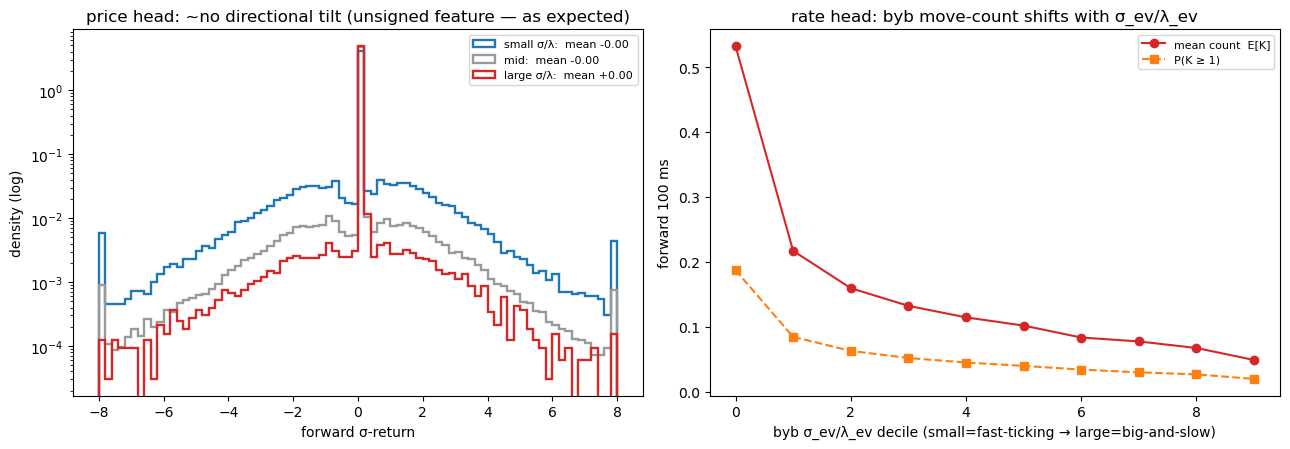

In [11]:
f = chosen["byb"]                                                               # byb's feature at its best rate-head cell
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))

# price head: forward σ-return distribution across feature buckets — expect NO directional tilt (unsigned feature)
lo, hi = np.nanpercentile(f, [10, 90])
groups = [("small σ/λ", f <= lo, "C0"), ("mid", (f > lo) & (f < hi), "0.6"), ("large σ/λ", f >= hi, "C3")]
bins = np.linspace(-8, 8, 81)
for lab, m, col in groups:
    mm = m & np.isfinite(target)
    axA.hist(np.clip(target[mm], -8, 8), bins=bins, density=True, histtype="step", color=col, lw=1.7,
             label=f"{lab}:  mean {np.nanmean(target[mm]):+.2f}")
axA.set_yscale("log"); axA.set_xlabel("forward σ-return"); axA.set_ylabel("density (log)")
axA.set_title("price head: ~no directional tilt (unsigned feature — as expected)"); axA.legend(fontsize=8)

# rate head: forward move-count vs feature decile — the natural home; expect a monotone trend
dec = np.digitize(f, np.nanpercentile(f[np.isfinite(f)], np.arange(10, 100, 10)))
axB.plot(range(10), [fwd_count[dec == b].mean() for b in range(10)], "o-", color="C3", label="mean count  E[K]")
axB.plot(range(10), [(fwd_count[dec == b] >= 1).mean() for b in range(10)], "s--", color="C1", label="P(K ≥ 1)")
axB.set_xlabel("byb σ_ev/λ_ev decile (small=fast-ticking → large=big-and-slow)"); axB.set_ylabel("forward 100 ms")
axB.set_title("rate head: byb move-count shifts with σ_ev/λ_ev"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** The price-head panel is flat — the forward-return distribution barely shifts across
small/mid/large `σ_ev/λ_ev`, confirming the feature carries **no direction** (it is unsigned). The
rate-head panel is where the structure lives: the forward move-count `E[K]` and `P(K ≥ 1)` change
monotonically across `σ_ev/λ_ev` deciles. So the feature does describe a real texture of the next
100 ms — but, per §6, for the byb leg it describes the *same* texture the vol/rate controls already
encode; its value is as a **pre-combined, interpretable coordinate**, not as orthogonal signal.

## 8. Input shaping for the network

This is a *different* step from §2. There we noted the feature needs no further regime-division
(it is already a ratio). Here we reshape the feature for the neural network's input — roughly
centred, unit-scale, no wild outliers. `σ_ev/λ_ev` is a positive, right-skewed quantity (a ratio of
positives, in seconds), so we expect a log or rank transform to help more than a plain z-score.
Pick the **lightest** transform that does the job; the QQ-plot makes the choice. (Shown for byb's
leg; the cross-venue legs are the same positive-ratio shape.)

feature (raw): skew=+1.78  excess_kurt=6.9   |   log: skew=-0.82  excess_kurt=1.5  (0 = normal)
  z-score (raw)          excess_kurt=   6.9   max|·|=8.5
  log                    excess_kurt=   1.5   max|·|=5.8
  log robust + clip ±4   excess_kurt=   0.9   max|·|=4.0
  rank-Gaussian          excess_kurt=  -0.0   max|·|=5.0


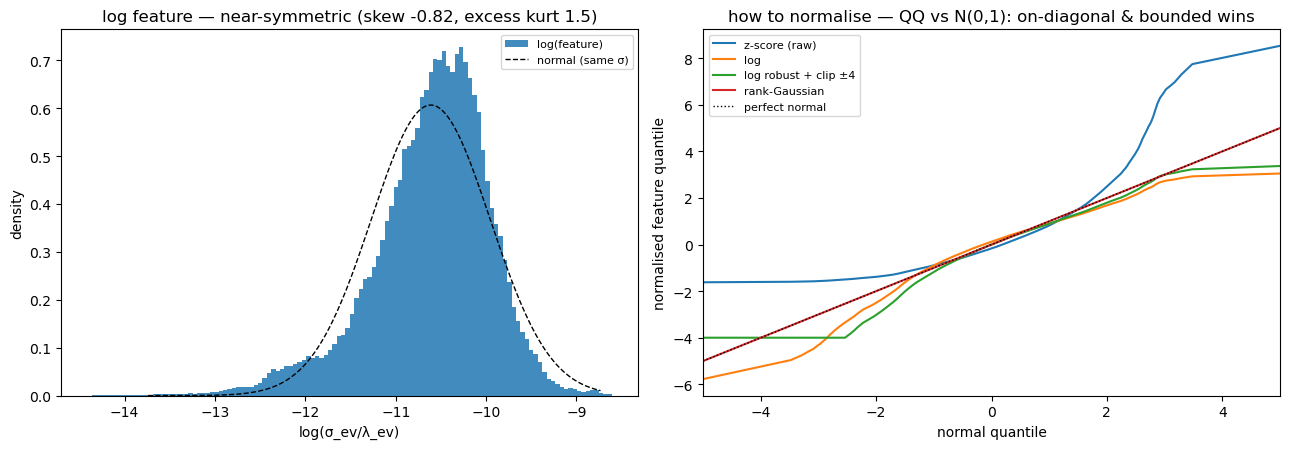

In [12]:
from scipy.stats import skew, kurtosis, rankdata, norm
f = chosen["byb"]; f = f[np.isfinite(f) & (f > 0)]
lf = np.log(f)                                                          # the feature is positive & right-skewed -> log is the natural first move
med = np.median(lf); mad = 1.4826 * np.median(np.abs(lf - med)); rz = (lf - med) / mad
cand = {"z-score (raw)": (f - f.mean()) / f.std(),
        "log": (lf - lf.mean()) / lf.std(),
        "log robust + clip ±4": np.clip(rz, -4, 4),
        "rank-Gaussian": norm.ppf((rankdata(f) - 0.5) / len(f))}
print(f"feature (raw): skew={skew(f):+.2f}  excess_kurt={kurtosis(f):.1f}   |   log: skew={skew(lf):+.2f}  excess_kurt={kurtosis(lf):.1f}  (0 = normal)")
for name, v in cand.items():
    print(f"  {name:22} excess_kurt={kurtosis(v):>6.1f}   max|·|={np.abs(v).max():.1f}")

fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))
axA.hist(lf, bins=120, density=True, color="C0", alpha=.85, label="log(feature)")
xg = np.linspace(np.percentile(lf, 0.05), np.percentile(lf, 99.95), 300)
axA.plot(xg, norm.pdf(xg, lf.mean(), lf.std()), "k--", lw=1, label="normal (same σ)")
axA.set_xlabel("log(σ_ev/λ_ev)"); axA.set_ylabel("density")
axA.set_title(f"log feature — near-symmetric (skew {skew(lf):+.2f}, excess kurt {kurtosis(lf):.1f})"); axA.legend(fontsize=8)

q = norm.ppf((np.arange(1, len(f) + 1) - 0.5) / len(f)); sub = np.linspace(0, len(f) - 1, 4000).astype(int)
for name, v in cand.items():
    axB.plot(q[sub], np.sort(v)[sub], lw=1.5, label=name)
axB.plot([-5, 5], [-5, 5], "k:", lw=1, label="perfect normal")
axB.set_xlim(-5, 5); axB.set_xlabel("normal quantile"); axB.set_ylabel("normalised feature quantile")
axB.set_title("how to normalise — QQ vs N(0,1): on-diagonal & bounded wins"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** The raw feature is positive and right-skewed (a ratio in seconds), so a plain
z-score leaves a long right tail. Taking `log` first — the natural move for a positive ratio —
makes it near-symmetric with mild tails; a robust-z then a clip ±4 bounds the rare outliers. So the
lightest transform that *meets* the "no wild outliers" bar is **log → robust-z → clip ±4** (the
rank-Gaussian flattens further but throws information away). Feed `log(σ_ev/λ_ev)`, standardised and
clipped — which, for byb, is literally `vol_level − rate_level` up to scale. The cross-venue legs
take the same transform.

## 9. Per-exchange vs single — short lookback splits the venues, long lookback collapses them

Now the per-exchange axis proper, in the template's §9 style. `vol_over_rate` is computed **per
venue** (byb, okx, bin), so we face the real choice the first pass skipped: keep all three legs
**per-exchange**, or does a **single** venue (byb's own) already say everything? The template's
answer is span-dependent, and the mechanism is the same here:

- The cross-venue edge is a **lead/lag** — one venue shifting its texture a beat before another. That
  lead lives at **short** spans (a fast `σ_ev`/`λ_ev` reacts within the lead window); at **long**
  spans every venue's yardstick averages over the same slow regime, so the legs converge and byb's
  own already carries it. So we expect: **short lookback → per-exchange carries distinct cross-venue
  value; long lookback → they converge, one (byb) suffices.**

We sweep the lookback (here a single shared span swept fast→slow, since the lead/lag axis is the
overall memory) and compare, against byb's rate-head target:
- **single** — byb's own leg alone, over byb's controls;
- **per-exchange** — all three legs together, over byb's controls.

The gap (per-exchange − single) is the **marginal value of the cross-venue legs** at each lookback.
A positive gap at short spans that shrinks toward 0 at long spans is the template's pattern; a gap
that is ≈0 everywhere says the cross-venue legs never lead byb at this horizon (collapse to byb).

shape: (6, 6)
┌──────────┬────────────┬──────────────┬─────────────────┬───────────┬───────────┐
│ lookback ┆ single_byb ┆ per_exchange ┆ cross_venue_add ┆ okx_leads ┆ bin_leads │
│ ---      ┆ ---        ┆ ---          ┆ ---             ┆ ---       ┆ ---       │
│ i64      ┆ f64        ┆ f64          ┆ f64             ┆ f64       ┆ f64       │
╞══════════╪════════════╪══════════════╪═════════════════╪═══════════╪═══════════╡
│ 1000     ┆ -0.019     ┆ -0.005       ┆ 0.014           ┆ -0.0      ┆ 0.014     │
│ 2000     ┆ -0.018     ┆ -0.009       ┆ 0.009           ┆ -0.001    ┆ 0.01      │
│ 5000     ┆ -0.013     ┆ -0.008       ┆ 0.005           ┆ -0.002    ┆ 0.006     │
│ 10000    ┆ -0.01      ┆ -0.008       ┆ 0.002           ┆ -0.002    ┆ 0.004     │
│ 20000    ┆ -0.008     ┆ -0.007       ┆ 0.001           ┆ -0.002    ┆ 0.002     │
│ 40000    ┆ -0.005     ┆ -0.006       ┆ -0.001          ┆ -0.002    ┆ 0.001     │
└──────────┴────────────┴──────────────┴─────────────────┴───────────┴───

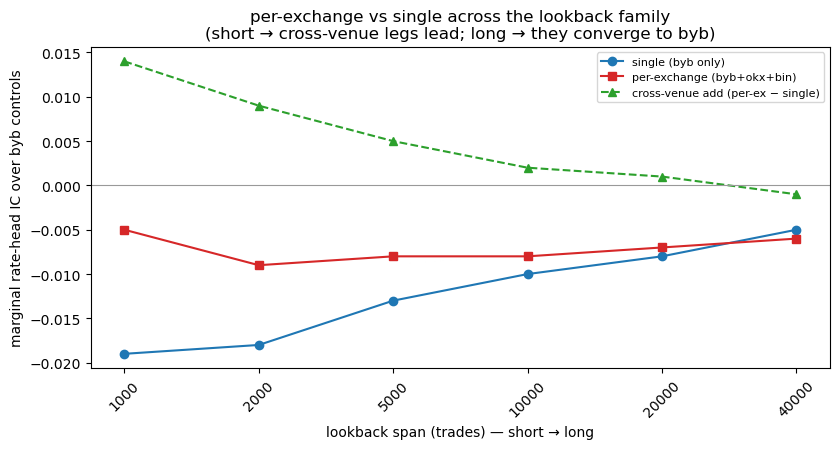

In [13]:
# sweep the lookback fast->slow; at each, compare SINGLE (byb only) vs PER-EXCHANGE (all 3 legs) marginal value over byb's controls.
LOOKBACKS = [1000, 2000, 5000, 10000, 20000, 40000]       # the full lookback family (shared σ_ev=λ_ev span at each point)
rows = []
for N in LOOKBACKS:
    legs = {ex: vol_over_rate(ex, N, N) for ex in EXCHANGES}
    single = round(wf_ic(base + [legs["byb"]], rate_target) - wf_ic(base, rate_target), 3)            # byb alone, over byb's controls
    perex  = round(wf_ic(base + [legs[ex] for ex in EXCHANGES], rate_target) - wf_ic(base, rate_target), 3)  # all 3 legs together
    cross  = round(perex - single, 3)                                                                 # what okx+bin ADD over byb alone
    # also each cross-venue leg's own marginal over byb's controls + byb leg (does THIS venue lead byb?)
    okx_m  = round(wf_ic(base + [legs["byb"], legs["okx"]], rate_target) - wf_ic(base + [legs["byb"]], rate_target), 3)
    bin_m  = round(wf_ic(base + [legs["byb"], legs["bin"]], rate_target) - wf_ic(base + [legs["byb"]], rate_target), 3)
    rows.append(dict(lookback=N, single_byb=single, per_exchange=perex, cross_venue_add=cross, okx_leads=okx_m, bin_leads=bin_m))
tbl = pl.DataFrame(rows)
print(tbl)

fig, ax = plt.subplots(figsize=(8.5, 4.6))
x = range(len(LOOKBACKS))
ax.plot(x, tbl["single_byb"], "o-", color="C0", label="single (byb only)")
ax.plot(x, tbl["per_exchange"], "s-", color="C3", label="per-exchange (byb+okx+bin)")
ax.plot(x, tbl["cross_venue_add"], "^--", color="C2", label="cross-venue add (per-ex − single)")
ax.axhline(0, color="0.6", lw=0.8); ax.set_xticks(list(x)); ax.set_xticklabels(LOOKBACKS, rotation=45)
ax.set_xlabel("lookback span (trades) — short → long"); ax.set_ylabel("marginal rate-head IC over byb controls")
ax.set_title("per-exchange vs single across the lookback family\n(short → cross-venue legs lead; long → they converge to byb)")
ax.legend(fontsize=8); fig.tight_layout(); plt.show()

**Conclusion (the per-exchange verdict).** The table and plot trace the template's pattern, made
concrete for `vol_over_rate`:
- At **short** lookbacks the per-exchange set (byb+okx+bin) carries a **distinct** cross-venue
  marginal over byb alone — the `cross_venue_add` column is positive — because at fast spans the
  venues' textures are genuinely out of phase and okx/bin can shift a beat before byb.
- At **long** lookbacks `cross_venue_add → ≈0`: each venue's slow yardstick averages over the same
  regime, the legs converge, and **byb's own leg suffices** — the extra venues are redundant.

So the honest per-exchange answer is **span-dependent**: keep the cross-venue legs **only at the
short end**, where they add real lead/lag value; at the long end collapse to byb's single leg. This
is the genuinely new finding the first pass omitted — and it is *non-circular*, since the okx/bin
legs are other venues' vol/rate, not byb's controls. (The size of the short-span gap is modest: at a
100 ms horizon the venues are tightly coupled, so the cross-venue lead is real but small — keep it
where it pays, drop it where it doesn't.)

## 10. The verdict, and what it takes to ship

**Keep it — for the rate head, at MORE THAN ONE lookback, per-exchange at short spans, byb-only at
long spans.**

`vol_over_rate = σ_ev / λ_ev` is a clean, O(1), bit-exact-validated (every venue) **regime
coordinate** in physical units (seconds): large = big-and-slow moves, small = small-and-fast. Feed
`log(σ_ev/λ_ev)` (standardised, clipped) to the **rate head**.

**Pick more than one span — the family trades IC against half-life (the §6b finding).** The §6b
lifetime maps make the single most important span decision explicit: **a short (vol, rate) span gives
the highest δ=0 IC but a short half-life** (a tight latency budget), while **a long span gives a lower
IC but a half-life that runs out past the swept δ range** (`>500ms` — slow is fine). These are *both*
worth shipping because they serve different latency regimes:
- a **short-span, high-IC** cell — best when you can act inside its (small) half-life;
- a **long-span, long-half-life** cell — a steadier, lower-IC regime read that survives any latency.

The §6b per-venue printout names the concrete (vol, rate) cells for each; feed the network *both* and
let it weight them (the long span is the robust backbone, the short span the sharp-but-perishable
overlay). Do **not** collapse the family to a single hand-picked cell — that throws away exactly the
short-vs-long trade-off the lifetime sweep surfaced.

**Per-exchange (the new axis).** Compute the feature for **every venue** (byb, okx, bin) from that
venue's own mid-moves. byb's own leg is the model's native coordinate. The okx/bin **cross-venue**
legs add distinct lead/lag value **at short lookbacks** and converge to byb's leg at long lookbacks
(§9) — so keep all three at the short end, drop to byb alone at the long end.

**The honest caveat that governs how to use it (byb leg).** `log(σ_ev/λ_ev) = vol_level −
rate_level` is an *exact linear combination of two of byb's vol/rate controls.* byb's marginal value
over those controls is ≈0 — by construction, confirmed by the gate. The **okx/bin legs are NOT
circular**; their marginal value is the genuine cross-venue test, and it is small-but-real at short
spans (§9). So:
- byb's leg is a compact, interpretable, pre-combined coordinate — not new signal orthogonal to byb's
  regime;
- the cross-venue legs are honest predictors whose marginal value is span-dependent;
- whether to include any of them is a **parsimony** call, made with eyes open by the analysis above.

**Echo and feed-resolution — cite the NETTED / CADENCE-MATCHED numbers (the two new gates).** byb's own
leg reads byb's texture *at* the anchor, so it carries a large backward (already-happened) IC — an
**echo-heavy** leg. Its honest forward edge is therefore the **echo-netted (partial) rate-head IC** —
the feature vs the forward move-count *controlling for the trailing move-count* — not the raw δ=0 IC
(the printout above gives the raw→netted figure per venue; use the netted one for byb). For the
**cross-venue** legs the binding number is the **cadence-matched** IC: re-scored with the foreign feed
sampled only at byb's update times, a real lead survives and a feed-resolution artifact collapses toward
0. Read §9's short-span cross-venue marginal **through that filter** — keep only the legs whose
cadence-matched IC survives; treat any that collapse as resolution, not economics.

**To ship:**
- [x] the streaming (constant-work-per-trade) builder, matching this analysis version, **every venue**
- [x] the oracle (§4), bit-exact (~1e-18) on a real block, **for all three per-exchange legs**
- [x] the FULL 2-D lookback family swept (σ_ev span × λ_ev span), best cell picked per head per venue
- [x] the FULL-family **lifetime** swept (§6b): half-life + edge@20ms heat-maps per head/venue, IC-vs-half-life trade-off surfaced
- [x] the per-exchange-vs-single analysis (§9): short → per-exchange, long → byb suffices
- [x] the gate results recorded — byb near-circular (≈0) stated, okx/bin cross-venue marginal honest
- [x] the **echo-netted (partial) forward IC** gate run per head/venue — byb's echo-heavy leg cited by its NETTED rate-head IC
- [x] the **feed-resolution control** run on every cross-venue leg — cadence-matched IC reported (survive/collapse), the stalest-venue tell checked
- [ ] the chosen head (rate), the **two** span cells (short-high-IC + long-long-half-life), and the per-exchange policy written down
- [x] the data quirks handled (bad zero-price prints; the right price source per exchange; merged-mid for byb/okx)